# Time Series Forecasting - Team 8

# Pre-process Dataset

In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display
from google.colab import drive

Optional: run the cell below to obtain the pre-processed train df to skip preprocessing runtime

In [10]:
if not os.path.exists("trained_processed.parquet"):
    !gdown --id 1E8qDLAOQufRefvKdttIY-WmkYnKYY9vw -O trained_processed.parquet

print("Loading data...")
train_df = pl.scan_parquet("trained_processed.parquet")
train_df = train_df.collect()

Loading data...


Or: manually run preprocessing using all the cells below

In [ ]:
# Step 1: Download (only if needed)
if not os.path.exists("train.parquet"):
    print("Downloading datasets...")
    !gdown --id 1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR -O train.parquet
if not os.path.exists("test.parquet"):
    !gdown --id 1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx -O test.parquet

# Step 2: Load (fast - local disk)
print("Loading data...")
train_df = pl.scan_parquet("train.parquet")
test_df  = pl.scan_parquet("test.parquet")
print("Data ready. Loading lazily...")

# Print schema
print(test_df.schema)

# Get shape (forces minimal computation)
print("\n\nTrain shape:", train_df.select(pl.len()).collect())
print("\n\nTest shape:", test_df.select(pl.len()).collect())

# Preview data (only loads small sample)
print("\n\nTraining data preview:")
display(train_df.head(5).collect())
print("\n\nTesting data preview:")
display(test_df.head(5).collect())

Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64, 'feature_am': Float64, 'feature_an'

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7



Testing data preview:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [ ]:
train_df = (
    pl.scan_parquet("train.parquet")
    .sort(["id", "code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

In [ ]:
EXCLUDE_COLS = [
    "id",
    "code",
    "sub_code",
    "sub_category",
    "ts_index",
    "y_target",
    "weight"
]

num_cols = [
    col for col in train_df.columns
    if col not in EXCLUDE_COLS
]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(["code", "sub_code", "sub_category"])
    .alias(col)
    for col in num_cols
])

#Median Imputation
global_medians = train_df.select([
    pl.col(col).median().alias(col)
    for col in num_cols
]).to_dict(as_series=False)

global_medians = {k: v[0] for k, v in global_medians.items()}

train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(global_medians[col])
    .alias(col)
    for col in num_cols
])

In [ ]:
#Test for nulls
print(train_df.select(
    pl.all().null_count()
))

shape: (1, 94)
┌─────┬──────┬──────────┬──────────────┬───┬────────────┬────────────┬──────────┬────────┐
│ id  ┆ code ┆ sub_code ┆ sub_category ┆ … ┆ feature_cg ┆ feature_ch ┆ y_target ┆ weight │
│ --- ┆ ---  ┆ ---      ┆ ---          ┆   ┆ ---        ┆ ---        ┆ ---      ┆ ---    │
│ u32 ┆ u32  ┆ u32      ┆ u32          ┆   ┆ u32        ┆ u32        ┆ u32      ┆ u32    │
╞═════╪══════╪══════════╪══════════════╪═══╪════════════╪════════════╪══════════╪════════╡
│ 0   ┆ 0    ┆ 0        ┆ 0            ┆ … ┆ 0          ┆ 0          ┆ 0        ┆ 0      │
└─────┴──────┴──────────┴──────────────┴───┴────────────┴────────────┴──────────┴────────┘


Summary Statistics

In [ ]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061148  ┆ 2.323426  ┆

Feature Distributions

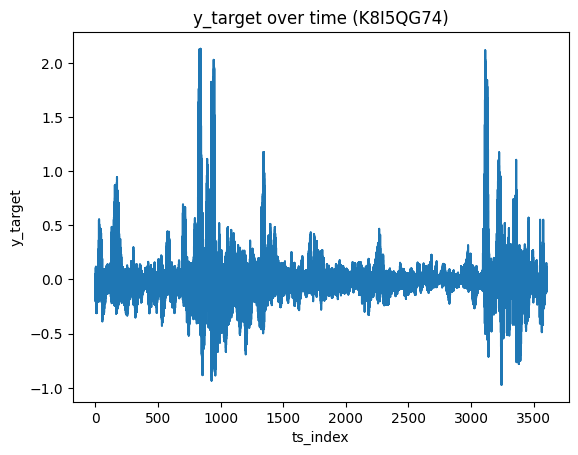

In [ ]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [11]:
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__3US8M659__PZ9S1Z4V__…","""10BAVIDU""","""3US8M659""","""PZ9S1Z4V""",3.0,2523,51.0,11.846471,0.963213,2.977301,13.993396,5.813456,13.908973,0.001669,0.000125,0.000053,0.000051,2.127237,0.814302,-0.685696,0.0,0.069483,1.354343,0.112513,5.643194,21.995209,0.878242,0.43134,5.458523,22.118563,29.57582,179.107101,0.0,0.035456,0.01005,1.052849,0.104493,…,0.018404,23.002231,212.888264,7.630392,164799.847687,288228.677995,181492.859849,-0.001152,258430.041099,10.168377,0.0,0.0,0.090889,849.053656,569.287972,804.908047,0.003178,0.218216,0.051946,-2.236405,-4.607988,-3.247761,0.034974,0.092308,0.258173,-0.307863,-0.036453,-0.022567,-0.363972,-0.387828,-0.01556,-0.00731,0.029991,0.034543,0.0,-2.811849,0.756535
"""WH61ASEA__XT8JWYHT__V8BKY1IV__…","""WH61ASEA""","""XT8JWYHT""","""V8BKY1IV""",25.0,3210,88.0,5.618197,11.850851,4.238244,14.500851,6.959052,7.23197,0.022803,0.000319,0.000022,0.000135,0.080695,0.15084,0.411745,0.083958,0.820167,3.435465,0.139073,3.034435,17.280441,43.869192,9.113672,-0.747115,-0.366864,-0.718933,-1.983457,0.014326,0.005793,0.0085,0.456843,1.943765,…,0.002583,0.333642,0.460519,0.0,4763.404216,89891.666974,3351.323203,0.0,54014.476309,0.204285,0.0,0.0,0.003306,623.628476,1335.07434,40.626956,0.036407,0.002046,0.001692,-5.337808,-4.121532,-0.980348,0.051199,0.174531,8.675864,-1.341054,-0.141241,-0.117993,-0.688207,-0.042566,-0.091875,-0.260366,2.19477,0.091535,5.0,18.587516,0.645589
"""1HEMHZK2__E4YOMGYN__NQ58FVQM__…","""1HEMHZK2""","""E4YOMGYN""","""NQ58FVQM""",1.0,2948,158.0,0.8903,12.661097,3.216802,14.993296,10.565785,0.638597,0.000369,0.008032,0.000249,0.008913,0.047178,1.799352,-0.013569,0.008647,0.000158,0.000638,0.000927,0.001039,0.003798,0.006938,0.038124,10.933108,-2.024263,-95.586264,-20.533905,0.015143,1.323964,1.821236,1.822553,0.009193,…,8.814963,12538.705615,985.821706,5058.84102,53839.490227,90115.380421,2823.398507,0.008139,5248.98421,18.423769,2374.473061,41.925662,15.283755,0.13616,2.527508,0.121771,0.666291,1.026584,0.90863,-0.273345,-1.514212,-4.361083,3.339388,0.233533,0.20725,-0.000452,-0.000099,-0.000657,-0.000051,-0.001247,-0.000056,-0.011025,1.447443,0.038155,3.0,-0.000235,2.6280e6
"""VFWIFJPS__FPY8XJGU__DPPUO5X2__…","""VFWIFJPS""","""FPY8XJGU""","""DPPUO5X2""",10.0,2067,109.0,13.576844,16.521271,8.118367,7.186189,9.176928,9.269126,0.006729,0.000195,0.000218,0.000397,1.613981,0.952116,2.8979e-19,0.000649,0.001208,0.001562,0.001238,0.000708,0.05989,0.03074,0.007192,53.039902,-9.998739,-16.623211,-10.839568,0.11757,0.122807,0.123096,2.046934,0.020228,…,21.380786,19259.91464,1826.155166,4482.302306,146916.405828,5485.131982,6186.054598,0.042119,3867.332396,0.490385,1038.27001,32.215065,9.839925,0.856057,0.115546,2.399179,2.163042,1.279994,1.568994,-0.365804,-0.091615,-0.117242,2.263631,5.366386,0.309877,-0.000051,-0.002519,-0.000075,-0.000066,-0.000095,-0.000551,0.001519,0.055892,1.871096,3.0,-0.004001,583396.345651
"""K7Y1TTAH__5AIUJMDO_

# Model Evaluation

In [12]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

import warnings
warnings.filterwarnings("ignore")

!pip install lightgbm
!pip install xgboost

SEED = 42

Next, we define the dataset with focus on features, weight and target.

In [24]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"

N_SPLITS = 5

SAMPLE_FRAC = 0.1
sample_size = int(len(train_df) * SAMPLE_FRAC)

train_df = (
    train_df
    .head(sample_size)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [ ]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    # Avoid division by zero
    if denom == 0:
        return 0.0

    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    score = 1.0 - clipped
    return np.sqrt(score)

In [ ]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Most importantly, we train the baseline model.

In [32]:
def train_model(X, y, w, splits, model):

    X_np = np.asarray(X)
    y_np = np.asarray(y).flatten()
    w_np = np.asarray(w).flatten()

    oof_predictions = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #scaling
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        #model
        fold_model = clone(model)
        fold_model.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = fold_model.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_predictions[val_idx] = preds

    return oof_predictions


hgbr_model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.11,
            max_depth=6,
            min_samples_leaf=20,
            l2_regularization=0.5,
            max_bins=255,
            validation_fraction=0.5,
            n_iter_no_change=60,
            random_state=SEED
        )

lightgbm_model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=0.5,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )

xgboost_model = XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=7,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1
        )

In [ ]:
tscv = TimeSeriesSplit(n_splits=5, gap=50)
splits = list(tscv.split(X))

oof_preds_hgbr = train_model(X, y, w, splits, hgbr_model)
fold_scores_hgbr, mean_rmse_hgbr, mean_mae_hgbr = compute_fold_metrics(y, oof_preds_hgbr, splits)
weighted_rmse_hgbr = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_hgbr,
    w.to_numpy().flatten()
)

oof_preds_lightgbm = train_model(X, y, w, splits, lightgbm_model)
fold_scores_lightgbm, mean_rmse_lightgbm, mean_mae_lightgbm = compute_fold_metrics(y, oof_preds_lightgbm, splits)
weighted_rmse_lightgbm = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_lightgbm,
    w.to_numpy().flatten()
)

oof_preds_xgboost = train_model(X, y, w, splits, xgboost_model)
fold_scores_xgboost, mean_rmse_xgboost, mean_mae_xgboost = compute_fold_metrics(y, oof_preds_xgboost, splits)
weighted_rmse_xgboost = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_xgboost,
    w.to_numpy().flatten()
)

print("\nHGBR Fold-wise scores:")
for f in fold_scores_hgbr:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_hgbr:.4f}, Mean MAE: {mean_mae_hgbr:.4f}, Weighted: {weighted_rmse_hgbr:.6f}")

print("\nLightBGM Fold-wise scores:")
for f in fold_scores_lightgbm:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_lightgbm:.4f}, Mean MAE: {mean_mae_lightgbm:.4f}, Weighted: {weighted_rmse_lightgbm:.6f}")

print("\nXGBoost Fold-wise scores:")
for f in fold_scores_xgboost:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_xgboost:.4f}, Mean MAE: {mean_mae_xgboost:.4f}, Weighted: {weighted_rmse_xgboost:.6f}")



HGBR Fold-wise scores:
Fold 1 - RMSE: 17.7048, MAE: 11.4809
Fold 2 - RMSE: 21.2527, MAE: 13.0918
Fold 3 - RMSE: 18.6743, MAE: 12.7535
Fold 4 - RMSE: 13.8862, MAE: 8.3065
Fold 5 - RMSE: 17.3768, MAE: 12.1571
Mean RMSE: 17.7790, Mean MAE: 11.5580, Weighted: 0.000000

LightBGM Fold-wise scores:
Fold 1 - RMSE: 18.0263, MAE: 12.4923
Fold 2 - RMSE: 21.2788, MAE: 13.7981
Fold 3 - RMSE: 18.1526, MAE: 12.3917
Fold 4 - RMSE: 13.2008, MAE: 7.8283
Fold 5 - RMSE: 17.4628, MAE: 12.2290
Mean RMSE: 17.6243, Mean MAE: 11.7479, Weighted: 0.000000

XGBoost Fold-wise scores:
Fold 1 - RMSE: 17.6041, MAE: 11.5575
Fold 2 - RMSE: 14.7656, MAE: 10.7240
Fold 3 - RMSE: 17.9374, MAE: 12.1296
Fold 4 - RMSE: 13.1262, MAE: 7.8994
Fold 5 - RMSE: 17.1888, MAE: 11.9599
Mean RMSE: 16.1244, Mean MAE: 10.8541, Weighted: 0.000000


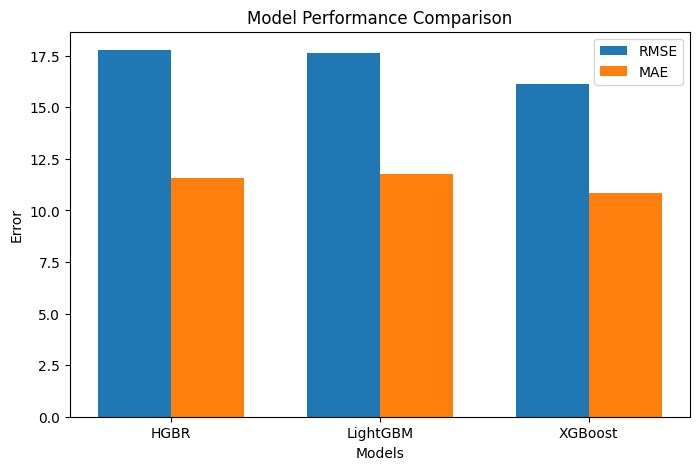

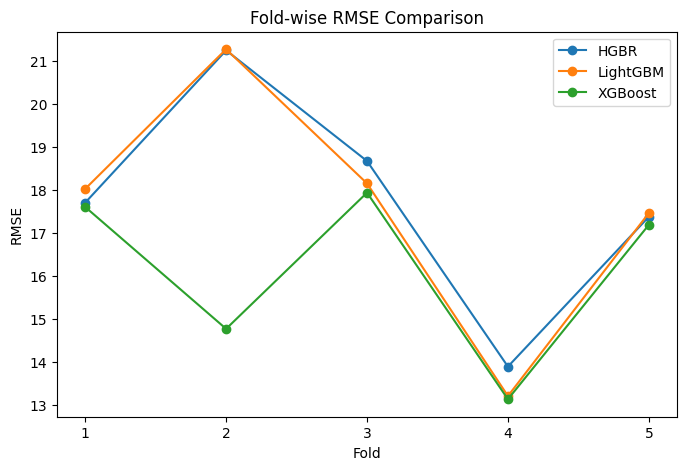

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Bar Graph
models = ["HGBR", "LightGBM", "XGBoost"]

rmse_scores = [
    mean_rmse_hgbr,
    mean_rmse_lightgbm,
    mean_rmse_xgboost
]

mae_scores = [
    mean_mae_hgbr,
    mean_mae_lightgbm,
    mean_mae_xgboost
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, rmse_scores, width, label="RMSE")
ax.bar(x + width/2, mae_scores, width, label="MAE")

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Error")
ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()
plt.show()


#Line Graph
folds = [1, 2, 3, 4, 5]

hgbr_rmse = [f["rmse"] for f in fold_scores_hgbr]
lgb_rmse = [f["rmse"] for f in fold_scores_lightgbm]
xgb_rmse = [f["rmse"] for f in fold_scores_xgboost]

plt.figure(figsize=(8, 5))

plt.plot(folds, hgbr_rmse, marker="o", label="HGBR")
plt.plot(folds, lgb_rmse, marker="o", label="LightGBM")
plt.plot(folds, xgb_rmse, marker="o", label="XGBoost")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Fold-wise RMSE Comparison")
plt.xticks(folds)

plt.legend()
plt.show()

# Feature Engineering

### Feature Importance

In [ ]:
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# =====================================
# Validation Splits
# =====================================
def time_splits(n):
    fold_size = n // (N_SPLITS + 1)

    splits = []
    for i in range(1, N_SPLITS + 1):
        train_end = i * fold_size
        val_end = (i + 1) * fold_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        splits.append((train_idx, val_idx))
    return splits

In [36]:
# =====================================
# Computing Temporal Feature Importance
# =====================================
def compute_temporal_importance(df, target, n_repeats=5):
    feature_df = df.select(
        pl.col("^feature.*$"),
        target
    )

    X = feature_df.drop(target)
    y = feature_df.select(target).to_numpy().ravel()

    X_np = X.to_numpy()
    feature_names = X.columns

    splits = time_splits(len(X_np))

    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"Processing fold {fold+1}")

        X_train = X_np[train_idx]
        y_train = y[train_idx]

        X_val = X_np[val_idx]
        y_val = y[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        perm = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=n_repeats,
            random_state=SEED,
            n_jobs=-1
        )

        all_importances.append(perm.importances_mean)

    importances_array = np.array(all_importances)

    mean_importance = importances_array.mean(axis=0)
    std_importance = importances_array.std(axis=0)

    stability_score = mean_importance / (std_importance + 1e-6)

    feature_importance_df = pl.DataFrame({
        "feature": feature_names,
        "mean_importance": mean_importance,
        "std_importance": std_importance,
        "stability_score": stability_score
    }).sort("mean_importance", descending=True)

    return feature_importance_df

# =====================================
# Selecting Features (based on stability + importance)
# =====================================
def select_features(
    feature_importance_df,
    unstable_threshold,
    stability_floor=0.5
):
    # Stable
    stable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > 0) &
            (pl.col("stability_score") > 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    # Unstable but useful
    unstable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > unstable_threshold) &
            (pl.col("stability_score") > stability_floor) &
            (pl.col("stability_score") <= 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    final_features = list(dict.fromkeys(
        stable_features + unstable_features
    ))

    print(f"Stable: {len(stable_features)}")
    print(f"Unstable added: {len(unstable_features)}")
    print(f"Final total: {len(final_features)}")
    print(f"Final Features: {final_features}")

    return final_features

### Compute Raw Features Importance

In [ ]:
# compute importance
importance_df = compute_temporal_importance(train_df, TARGET)

# inspect and select thresholds
print(importance_df.select("mean_importance").describe())

threshold = 0.01

# select features
final_features = select_features(
    importance_df,
    unstable_threshold=threshold
)

Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.009872        │
│ std        ┆ 0.025877        │
│ min        ┆ -0.017272       │
│ 25%        ┆ -0.000077       │
│ 50%        ┆ 0.001876        │
│ 75%        ┆ 0.005777        │
│ max        ┆ 0.142759        │
└────────────┴─────────────────┘
Stable: 14
Unstable added: 8
Final total: 22
Final Features: ['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [14]:
#Loads final features from Google Drive instantaneously
import json

if not os.path.exists("final_features.json"):
    print("Downloading final features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O final_features.json
assert os.path.exists("final_features.json"), "Download failed!"


with open("/content/final_features.json", "r") as f:
    final_features = json.load(f)

print(final_features)

['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [16]:
#Obtain the final feature columns
if not os.path.exists("final_features.parquet"):
    print("Downloading dataset...")
    !gdown --id 1mDjBRCZiR-yCA8KnzQPkdBn-lcLWTOUV -O final_features.parquet
assert os.path.exists("final_features.parquet"), "Download failed!"

#Assigned final feature columns to variable. important!
print("Loading data...")
final_df = pl.scan_parquet("final_features.parquet")
print("Processed final feature dataset.")
print(final_df.collect())

Loading data...
Processed final feature dataset.
shape: (533_741, 22)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ feature_b ┆ feature_b ┆ feature_a ┆ feature_b ┆ … ┆ feature_a ┆ feature_l ┆ feature_a ┆ feature_ │
│ z         ┆ p         ┆ l         ┆ m         ┆   ┆ f         ┆ ---       ┆ m         ┆ by       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -0.000112 ┆ 1.624992  ┆ 0.036769  ┆ 0.080796  ┆ … ┆ 0.001075  ┆ 0.046895  ┆ 0.005416  ┆ -0.00356 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 4        │
│ -1.482432 ┆ 0.000251  ┆ 0.070621  ┆ 7181.5568 ┆ … ┆ 464.32024 ┆ 2.127275  ┆ 27.39086  ┆ -0.14354 │
│           ┆        

### Compute Horizon Feature Importance

In [ ]:
horizon_feature_sets = {}

for h in [1, 3, 10, 25]:
  print(f"\n==== Horizon {h} ====")

  df_h = train_df.filter(pl.col("horizon") == h)

  # compute importance
  importance_df = compute_temporal_importance(df_h, TARGET)

  # inspect and select thresholds
  print(importance_df.select("mean_importance").describe())

  threshold = 0.01

  # select features
  final_features = select_features(
      importance_df,
      unstable_threshold=threshold
  )

  horizon_feature_sets[h] = final_features


==== Horizon 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.001793        │
│ std        ┆ 0.007565        │
│ min        ┆ -0.003083       │
│ 25%        ┆ -0.000249       │
│ 50%        ┆ 0.000145        │
│ 75%        ┆ 0.001057        │
│ max        ┆ 0.066025        │
└────────────┴─────────────────┘
Stable: 6
Unstable added: 1
Final total: 7
Final Features: ['feature_o', 'feature_af', 'feature_bz', 'feature_s', 'feature_aj', 'feature_cd', 'feature_as']

==== Horizon 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │


In [18]:
#Outputs and downloads horizon feature sets instantaneously from drive
import json

if not os.path.exists("horizon_feature_sets.json"):
    print("Downloading horizon features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O horizon_feature_sets.json
assert os.path.exists("horizon_feature_sets.json"), "Download failed!"

with open("/content/horizon_feature_sets.json", "r") as f:
    horizon_feature_sets = json.load(f)

print(horizon_feature_sets)

['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


### Compute Lag Feature Importance

In [19]:
#Lag Features Instant Output
import os
import polars as pl

if not os.path.exists("lag_features.parquet"):
        print("Downloading results...")
        !gdown --id 1GgqMlFgNpuIas2RbzoyUR9dGPrnPvH-3 -O lag_features.parquet

print("Loading data...")
lag_results = pl.scan_parquet("lag_features.parquet").collect()
print(lag_results)


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1GgqMlFgNpuIas2RbzoyUR9dGPrnPvH-3
To: /content/lag_features.parquet
100% 990/990 [00:00<00:00, 5.70MB/s]
Loading data...
shape: (8, 2)
┌───────────────────────────┬──────┐
│ feature                   ┆ type │
│ ---                       ┆ ---  │
│ str                       ┆ str  │
╞═══════════════════════════╪══════╡
│ feature_lag_10_feature_ai ┆ lag  │
│ feature_lag_1_feature_ah  ┆ lag  │
│ feature_lag_1_feature_aj  ┆ lag  │
│ feature_lag_1_feature_be  ┆ lag  │
│ feature_lag_1_feature_bz  ┆ lag  │
│ feature_lag_3_feature_ai  ┆ lag  │
│ feature_lag_3_feature_z   ┆ lag  │
│ feature_lag_5_feature_bs  ┆ lag  │
└───────────────────────────┴──────┘


In [ ]:
# Generate lag features
def generate_lags(df, feature_cols, lag, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
          lag_exprs.append (
              pl.col(col)
              .shift(lag)
              .over(group_col)
              .alias(f"feature_lag_{lag}_{col}")
          )
    return df.with_columns(lag_exprs)


# Lags to evaluate
lags = [1, 3, 5, 10, 25]

results = []
selected_lag_features = []

for lag in lags:
    print(f"\n==== Testing lag: {lag} ====")

    # Generate lag features
    df_lagged = generate_lags(train_df.clone(), FEATURES, lag, [CODE, SUBCODE, SUBCATEGORY])

    # Compute temporal importance
    importance_df = compute_temporal_importance(df_lagged, TARGET)

    # Extract lag feature stats
    lag_features = [f"feature_lag_{lag}_{col}" for col in FEATURES]

    lag_importance = (
          importance_df
          .filter(pl.col("feature").is_in(lag_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

    selected_features_df = lag_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
    )

    filtered_lag_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
    )

    selected_lag_features.extend(filtered_lag_features)
    selected_lag_features = sorted(set(selected_lag_features))

    # Stats
    num_signal = lag_importance.filter(pl.col("mean_importance") > 0).height
    avg_importance = lag_importance["mean_importance"].mean()
    avg_stability = lag_importance["stability_score"].mean()
    avg_score = lag_importance["score"].mean()

    print(f"Lag features with signal: {num_signal}")
    print(f"Avg importance: {avg_importance}")
    print(f"Avg stability: {avg_stability}")
    print(f"Avg score: {avg_score}")

    print("\nTop lag features:")
    print(lag_importance.head(10))

    print(f"\nSelected features for lag {lag}:")
    print(filtered_lag_features)

    # Store results
    results.append({
        "lag": lag,
        "avg_lag_importance": avg_importance,
        "avg_lag_stability": avg_stability,
        "avg_score": avg_score,
        "top_lag_features": lag_importance.head(5),
        "selected_features": filtered_lag_features
    })

print("\n==== FINAL SELECTED LAG FEATURES ====")
print(selected_lag_features)
print(f"Total selected lag features: {len(selected_lag_features)}")


==== Testing lag: 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Lag features with signal: 59
Avg importance: 0.0021302505329754526
Avg stability: 0.2904225861727805
Avg score: 0.002264764525231278

Top lag features:
shape: (10, 5)
┌──────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                  ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                      ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                      ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞══════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_lag_1_feature_bz ┆ 0.039848        ┆ 0.036903       ┆ 1.079757        ┆ 0.041406 │
│ feature_lag_1_feature_v  ┆ 0.027048        ┆ 0.046529       ┆ 0.581291        ┆ 0.020622 │
│ feature_lag_1_feature_z  ┆ 0.011397        ┆ 0.011889       ┆ 0.

### Rolling Window Features

In [20]:
#Rolling Window Feature Instant Output(MEAN)
import os
import polars as pl

if not os.path.exists("rolling_mean_features.parquet"):
        print("Downloading results...")
        !gdown --id 1ojdCQgLjr5tYsbM64SzzCk2HZGp8idO5 -O rolling_mean_features.parquet

print("Loading data...")
rolling_mean_results = pl.scan_parquet("rolling_mean_features.parquet").collect()
print(rolling_mean_results)

#Rolling Window Feature Instant Output(STD)
import os
import polars as pl

if not os.path.exists("rolling_std_features.parquet"):
        print("Downloading results...")
        !gdown --id 1vbT9RHLLTLfMV92FrCQBKOcqTyHbF64O -O rolling_std_features.parquet

print("Loading data...")
rolling_std_features_results = pl.scan_parquet("rolling_std_features.parquet").collect()
print(rolling_std_features_results)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1ojdCQgLjr5tYsbM64SzzCk2HZGp8idO5
To: /content/rolling_mean_features.parquet
100% 1.20k/1.20k [00:00<00:00, 6.19MB/s]
Loading data...
shape: (12, 2)
┌─────────────────────────────────┬──────────────┐
│ feature                         ┆ type         │
│ ---                             ┆ ---          │
│ str                             ┆ str          │
╞═════════════════════════════════╪══════════════╡
│ feature_rolling_mean_3_feature… ┆ rolling_mean │
│ feature_rolling_mean_5_feature… ┆ rolling_mean │
│ feature_rolling_mean_10_featur… ┆ rolling_mean │
│ feature_rolling_mean_3_feature… ┆ rolling_mean │
│ feature_rolling_mean_3_feature… ┆ rolling_mean │
│ …                               ┆ …            │
│ feature_rolling

In [ ]:
def generate_rolling(df, feature_cols, window, group_col=CODE, stat="mean"):
    rolling_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).shift(1)

        if "mean" == stat:
                rolling_exprs.append(
                    shifted.rolling_mean(window).over(group_col)
                    .alias(f"feature_rolling_mean_{window}_{col}")
                )

        elif "std" == stat:
                rolling_exprs.append(
                    shifted.rolling_std(window).over(group_col)
                    .alias(f"feature_rolling_std_{window}_{col}")
                )

        elif "skew" == stat:
                rolling_exprs.append(
                    shifted.rolling_skew(window).over(group_col)
                    .alias(f"feature_rolling_skew_{window}_{col}")
                )

        elif "kurt" == stat:
                rolling_exprs.append(
                    shifted.rolling_kurtosis(window).over(group_col)
                    .alias(f"feature_rolling_kurt_{window}_{col}")
                )

        else:
            raise ValueError(f"Unknown stat: {stat}")

    return df.with_columns(rolling_exprs)


# Rolling Windows
windows = [3, 5, 10, 25]

def test_rolling_window(stat):
  results = []
  all_selected_features = []

  for window in windows:
      print(f"\n==== Testing window: {window} ====")

      df_roll = generate_rolling(train_df.clone(), FEATURES, window, [CODE, SUBCODE, SUBCATEGORY], stat)

      importance_df = compute_temporal_importance(df_roll, TARGET)

      roll_features = [
          f"feature_rolling_{stat}_{window}_{col}"
          for col in FEATURES
      ]

      roll_importance = (
          importance_df
          .filter(pl.col("feature").is_in(roll_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

      selected_features_df = roll_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
      )

      selected_rolling_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
      )

      all_selected_features.extend(selected_rolling_features)
      all_selected_features = list(set(all_selected_features))

      # Stats
      num_signal = roll_importance.filter(pl.col("mean_importance") > 0).height
      avg_importance = roll_importance["mean_importance"].mean()
      avg_stability = roll_importance["stability_score"].mean()
      avg_score = roll_importance["score"].mean()

      print(f"Rolling features with signal: {num_signal}")
      print(f"Avg importance: {avg_importance}")
      print(f"Avg stability: {avg_stability}")
      print(f"Avg score: {avg_score}")

      print("\nTop rolling features:")
      print(roll_importance.head(10))

      results.append({
          "window": window,
          "num_signal": num_signal,
          "avg_importance": avg_importance,
          "avg_stability": avg_stability,
          "avg_score": avg_score,
          "top_features": roll_importance.head(5),
          "selected_features": selected_rolling_features
      })

  return results, all_selected_features

Rolling Window Mean

In [ ]:
results, selected_rolling_features = test_rolling_window("mean")


==== Testing window: 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Rolling features with signal: 61
Avg importance: 0.0032753215441700696
Avg stability: 0.3078922926751945
Avg score: 0.0032414673550067324

Top rolling features:
shape: (10, 5)
┌─────────────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                         ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                             ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                             ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_rolling_mean_3_feature… ┆ 0.094939        ┆ 0.113204       ┆ 0.838648        ┆ 0.086943 │
│ feature_rolling_mean_3_feature… ┆ 0.022435        ┆ 0.025848       ┆ 0.867919        ┆ 0.020901 │
│ fea

Rolling Window STD

In [ ]:
results, selected_rolling_features = test_rolling_window("std")


==== Testing window: 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Rolling features with signal: 59
Avg importance: 0.0005112194205008025
Avg stability: 0.26617557750779797
Avg score: 0.0007030787863711041

Top rolling features:
shape: (10, 5)
┌─────────────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                         ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                             ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                             ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_rolling_std_3_feature_… ┆ 0.007132        ┆ 0.007582       ┆ 0.940416        ┆ 0.006916 │
│ feature_rolling_std_3_feature_… ┆ 0.006251        ┆ 0.005503       ┆ 1.135679        ┆ 0.006662 │
│ fe

### Horizon Based Features

In [21]:
import os
import polars as pl

if not os.path.exists("horizon_based_features_j.parquet"):
        print("Downloading results...")
        !gdown --id 11z6ZhNHfimxj8W2rwhmTgiH3rLx0tilv -O horizon_based_features_j.parquet

print("Loading data...")
h_results = pl.scan_parquet("horizon_based_features_j.parquet").collect()
print(h_results)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11z6ZhNHfimxj8W2rwhmTgiH3rLx0tilv
To: /content/horizon_based_features_j.parquet
100% 895k/895k [00:00<00:00, 37.3MB/s]
Loading data...
shape: (533_741, 3)
┌────────────┬──────────────────┬─────────┐
│ feature_ah ┆ feature_ah_x_h25 ┆ horizon │
│ ---        ┆ ---              ┆ ---     │
│ f64        ┆ f32              ┆ f64     │
╞════════════╪══════════════════╪═════════╡
│ 4.399618   ┆ 0.0              ┆ 1.0     │
│ 4.399618   ┆ 0.0              ┆ 10.0    │
│ 4.399618   ┆ 0.0              ┆ 3.0     │
│ 4.399618   ┆ 4.399618         ┆ 25.0    │
│ 4.370596   ┆ 0.0              ┆ 10.0    │
│ …          ┆ …                ┆ …       │
│ 5.711266   ┆ 0.0              ┆ 1.0     │
│ 5.428882   ┆ 0.0              ┆ 1.0     │


In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.base import clone

# =========================================================
# CONFIG
# =========================================================

def get_important_base_features(
    X_base,
    y_base,
    target,
    excluded_cols=None,
    importance_threshold=0.01,
    stability_floor=0.5,
    top_k=None
):

    # -----------------------------------------
    # Default exclusions
    # -----------------------------------------

    if excluded_cols is None:
        excluded_cols = set()

    # -----------------------------------------
    # Importance computation
    # -----------------------------------------

    importance_input = X_base.hstack(y_base)

    base_importance = compute_temporal_importance(
        importance_input,
        target
    )

    # -----------------------------------------
    # Remove metadata columns
    # -----------------------------------------

    base_importance = (
        base_importance
        .filter(
            ~pl.col("feature").is_in(excluded_cols)
        )
    )

    # -----------------------------------------
    # Stability-adjusted scoring
    # -----------------------------------------

    base_importance = (
        base_importance
        .with_columns(
            (
                pl.col("mean_importance") *
                pl.col("stability_score")
                .clip(lower_bound=0)
                .sqrt()
            ).alias("score")
        )
        .sort("score", descending=True)
    )

    # -----------------------------------------
    # Threshold filtering
    # -----------------------------------------

    filtered = (
        base_importance
        .filter(
            (pl.col("mean_importance") > importance_threshold) &
            (pl.col("stability_score") >= stability_floor)
        )
    )

    # -----------------------------------------
    # Optional top-k truncation
    # -----------------------------------------

    if top_k is not None:
        filtered = filtered.head(top_k)

    selected_features = filtered["feature"].to_list()

    return (
        selected_features,
        filtered
    )

# =========================================================
# BASE DATA
# =========================================================

X_base = (
    X.clone()
    .with_columns(
        train_df["horizon"]
            .alias("horizon")
    )
)

EXCLUDED_COLS = {
    TARGET,
    "horizon",
    "code",
    "sub_code",
    "ts_index"
}

y_base = train_df.select(TARGET)

important_cols, base_importance = (
    get_important_base_features(
        X_base,
        y_base,
        TARGET,
        excluded_cols=EXCLUDED_COLS,
        importance_threshold=0.01,
        stability_floor=0.7,
        top_k=8
    )
)

horizon_sensitive_cols = (
    base_importance
    .filter(
        pl.col("stability_score") < 0.8
    )
    ["feature"]
    .to_list()
)

important_cols=horizon_sensitive_cols

# =========================================================
# HORIZON FEATURE ENGINEERING
# =========================================================

def create_horizon_features(
    X,
    important_cols,
    horizons=(1, 3, 10, 25)
):
    X_new = X.clone()

    interaction_features = []
    exprs = []

    # -------------------------------------------------
    # Horizon dummy + interaction features
    # -------------------------------------------------

    for horizon in horizons:

        # -----------------------------
        # Horizon dummy feature
        # -----------------------------

        dummy_col = f"is_h{horizon}"

        exprs.append(
            (
                pl.col("horizon") == horizon
            )
            .cast(pl.Float32)
            .alias(dummy_col)
        )

        interaction_features.append(dummy_col)

        # -----------------------------
        # Horizon interaction features
        # -----------------------------

        horizon_mask = (
            pl.col("horizon") == horizon
        ).cast(pl.Float32)

        for col in important_cols:

            if col == "horizon":
              continue

            if col not in X_new.columns:
                continue

            new_col = f"{col}_x_h{horizon}"

            exprs.append(
                (
                    pl.col(col).cast(pl.Float32) * horizon_mask
                ).alias(new_col)
            )

            interaction_features.append(new_col)

    # -------------------------------------------------
    # Apply all expressions once
    # -------------------------------------------------

    X_new = X_new.with_columns(exprs)

    return X_new, interaction_features

# =========================================================
# HORIZON FEATURE PIPELINE
# =========================================================

def build_horizon_pipeline(
    X_base,
    y_base,
    target,
    important_cols,
    unstable_threshold=0.002
):

    # -----------------------------------------
    # Feature generation
    # -----------------------------------------

    X_horizon, created_features = (
    create_horizon_features(
        X_base,
        important_cols,
        horizons=(1, 3, 10, 25)
    )
)

    print(f"Original shape: {X_base.shape}")
    print(f"New shape: {X_horizon.shape}")

    # -----------------------------------------
    # Importance evaluation
    # -----------------------------------------

    importance_input = X_horizon.hstack(y_base)

    importance_df = compute_temporal_importance(
        importance_input,
        target
    )

    # -----------------------------------------
    # Horizon-only filtering
    # -----------------------------------------

    horizon_feature_set = created_features

    horizon_importance = (
        importance_df
        .filter(
            pl.col("feature")
            .is_in(horizon_feature_set)
        )
        .with_columns(
            (
                pl.col("mean_importance") *
                pl.col("stability_score")
                .clip(lower_bound=0)
                .sqrt()
            ).alias("score")
        )
        .sort("score", descending=True)
    )

    # -----------------------------------------
    # Feature selection
    # -----------------------------------------

    selected_features = select_features(
        horizon_importance,
        unstable_threshold=unstable_threshold,
        stability_floor=0.5
    )

    # -----------------------------------------
    # Diagnostics
    # -----------------------------------------

    diagnostics = {
        "num_signal": (
            horizon_importance
            .filter(pl.col("mean_importance") > 0)
            .height
        ),
        "avg_importance": (
            horizon_importance["mean_importance"]
            .mean()
        ),
        "avg_stability": (
            horizon_importance["stability_score"]
            .mean()
        ),
        "avg_score": (
            horizon_importance["score"]
            .mean()
        )
    }

    print("\n===================================")
    print("HORIZON FEATURE SUMMARY")
    print("===================================")

    for k, v in diagnostics.items():
        print(f"{k}: {v}")

    print("\nTop Horizon Features:")
    print(horizon_importance.head(10))

    print("\nSelected Features:")
    print(selected_features)

    return (
        X_horizon,
        horizon_importance,
        selected_features
    )

# =========================================================
# RUN PIPELINE
# =========================================================

(
    X_horizon,
    horizon_importance,
    selected_horizon_features
) = build_horizon_pipeline(
    X_base=X_base,
    y_base=y_base,
    target=TARGET,
    important_cols=important_cols
)

# =========================================================
# FINAL FEATURE MATRIX
# =========================================================

final_features = list(dict.fromkeys(
    important_cols +
    selected_horizon_features +
    ["horizon"]
))

X_final = X_horizon.select(final_features)

## Trend/Difference Feature

In [22]:
import os
import polars as pl

if not os.path.exists("diff_features.parquet"):
        print("Downloading results...")
        !gdown --id 1unudPl7lqVkFxg5jX-PLkvV7SfIfNIat -O diff_features.parquet

print("Loading data...")
diff_results = pl.scan_parquet("diff_features.parquet").collect()
print(diff_results)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1unudPl7lqVkFxg5jX-PLkvV7SfIfNIat
To: /content/diff_features.parquet
100% 1.05k/1.05k [00:00<00:00, 5.05MB/s]
Loading data...
shape: (14, 2)
┌─────────────────────────┬────────────┐
│ feature                 ┆ type       │
│ ---                     ┆ ---        │
│ str                     ┆ str        │
╞═════════════════════════╪════════════╡
│ feature_diff_feature_bm ┆ difference │
│ feature_diff_feature_bz ┆ difference │
│ feature_diff_feature_bo ┆ difference │
│ feature_diff_feature_k  ┆ difference │
│ feature_diff_feature_i  ┆ difference │
│ …                       ┆ …          │
│ feature_diff_feature_r  ┆ difference │
│ feature_diff_feature_aj ┆ difference │
│ feature_diff_feature_ay ┆ difference │
│ feature_di

In [ ]:
#Create Difference Features
def generate_diff_features(df, feature_cols, group_col=CODE):
    diff_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).over(group_col)
        diff_exprs.append(
            (shifted - shifted.shift(1))
            .alias(f"feature_diff_{col}")
        )

    return df.with_columns(diff_exprs)

#Apply to Dataset
results = []

print("\n==== Testing Difference Features ====")

# Generate difference features
df_diff = generate_diff_features(
    train_df.clone(),
    FEATURES,
    [CODE, SUBCODE, SUBCATEGORY]
)

# Compute importance
importance_df = compute_temporal_importance(df_diff, TARGET)

# Extract difference features
diff_features = [f"feature_diff_{col}" for col in FEATURES]

diff_importance = (
    importance_df
    .filter(pl.col("feature").is_in(diff_features))
    .with_columns(
        (
            pl.col("mean_importance") *
            pl.col("stability_score")
                .clip(lower_bound=0)
                .log1p()
        ).alias("score")
    )
    .sort("score", descending=True)
)

selected_features_df = diff_importance.filter(
    (pl.col("mean_importance") > 0.001) &
    (pl.col("stability_score") > 0.5)
)

selected_diff_features = (
    selected_features_df
    .sort("score", descending=True)
    .get_column("feature")
    .to_list()
)

# Stats
num_signal = diff_importance.filter(pl.col("mean_importance") > 0).height
avg_importance = diff_importance["mean_importance"].mean()
avg_stability = diff_importance["stability_score"].mean()
avg_score = diff_importance["score"].mean()

print(f"Difference features with signal: {num_signal}")
print(f"Avg importance: {avg_importance}")
print(f"Avg stability: {avg_stability}")
print(f"Avg score: {avg_score}")

print("\nTop difference features (by score):")
print(diff_importance.head(10))

# Store results
results.append({
    "feature_type": "difference",
    "num_signal": num_signal,
    "avg_importance": avg_importance,
    "avg_stability": avg_stability,
    "avg_score": avg_score,
    "top_features": diff_importance.head(5),
    "selected_features": selected_diff_features
})


==== Testing Difference Features ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Difference features with signal: 57
Avg importance: 0.000606166002553512
Avg stability: 0.27479240246773934
Avg score: 0.0005741761036042129

Top difference features (by score):
shape: (10, 5)
┌─────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                 ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                     ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                     ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_diff_feature_bm ┆ 0.008677        ┆ 0.005092       ┆ 1.703726        ┆ 0.00863  │
│ feature_diff_feature_bz ┆ 0.013968        ┆ 0.022947       ┆ 0.608667        ┆ 0.00664  │
│ feature_diff_feature_bo ┆ 0.0053

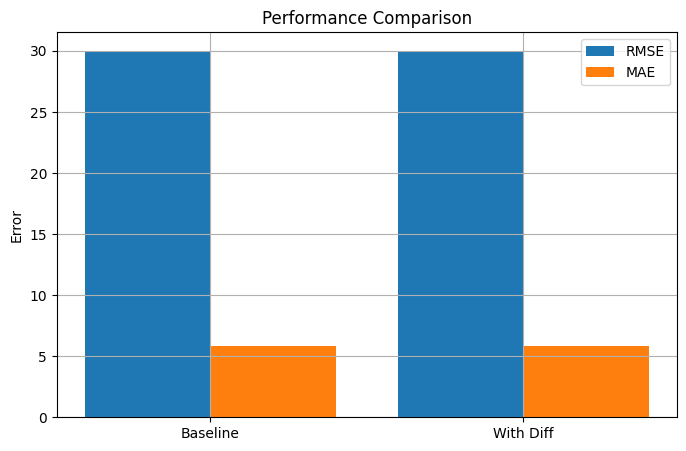

In [ ]:
labels = ["Baseline", "With Diff"]

rmse_vals = [mean_rmse, mean_rmse_diff]
mae_vals = [mean_mae, mean_mae_diff]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, rmse_vals, width=0.4, label="RMSE")
plt.bar(x + 0.2, mae_vals, width=0.4, label="MAE")

plt.xticks(x, labels)
plt.title("Performance Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Trend/Difference feature
The introduction of lag-1 difference features (x_t - x_{t-1}) was intended to capture short-term temporal changes within each code group, allowing the model to detect sudden deviations or behavioral shifts that may not be visible in the raw feature values alone. However, the experimental results show that including these features did not produce any measurable improvement in performance. Both RMSE and MAE remained essentially unchanged compared to the baseline model, indicating that the additional features did not contribute meaningful predictive signal.

This suggests that the original feature set already contains sufficient information for the model, or that the model itself is capable of implicitly learning temporal relationships without explicitly engineered difference features. It is also possible that the dataset does not exhibit strong short-term variation, or that differencing introduced noise that offset any potential benefit. As a result, the lag-1 difference features do not justify inclusion in the final model, reinforcing the importance of empirically validating feature engineering choices rather than assuming their effectiveness.

## Group-Based Feature




In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import gc
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

SEED       = 42
ID         = "id"
CODE       = "code"
SUBCODE    = "sub_code"
SUBCATEGORY= "sub_category"
HORIZON    = "horizon"
TS_INDEX   = "ts_index"
TARGET     = "y_target"
WEIGHT     = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"
SAMPLE_FRAC  = 0.1
N_SPLITS     = 5

EXCLUDE_COLS = [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX,
                TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]

print("=" * 65)
print("  Cell 17 — Group-Based Feature Engineering & Evaluation")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Reload the processed training data (same slice as baseline)
# ─────────────────────────────────────────────────────────────────────────────
print("\n[1/4] Loading processed training data …")

train_raw = (
    pl.scan_parquet("train_processed.parquet")
    .collect()
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

print(f"    Loaded {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")



  Cell 17 — Group-Based Feature Engineering & Evaluation

[1/4] Loading processed training data …
    Loaded 533,741 rows × 96 columns


In [ ]:
# Group-Based Aggregations

print("\n[2/4] Engineering group-based aggregation features …")

GROUP_LEVELS = [CODE, SUBCODE, SUBCATEGORY]

AGG_EXPRS = []
for grp in GROUP_LEVELS:
    safe = grp.replace("/", "_")
    AGG_EXPRS += [
        pl.col(TARGET).mean().over(grp).alias(f"grp_mean_{safe}"),
        pl.col(TARGET).std().over(grp).alias(f"grp_std_{safe}"),
        pl.col(TARGET).median().over(grp).alias(f"grp_median_{safe}"),
        # ratio of current value to group mean (relative position)
        (pl.col(TARGET) / (pl.col(TARGET).mean().over(grp) + 1e-8))
            .alias(f"grp_ratio_{safe}"),
        # rolling mean within group (window = 5)
        pl.col(TARGET)
            .rolling_mean(window_size=5)
            .over(grp)
            .alias(f"grp_roll5_{safe}"),
        # rolling std within group (window = 5) — local volatility proxy
        pl.col(TARGET)
            .rolling_std(window_size=5)
            .over(grp)
            .alias(f"grp_rollstd5_{safe}"),
    ]

train_eng = train_raw.with_columns(AGG_EXPRS)

# ── Within-group Z-score normalisation (STEP 2b) ────────────────────────────
print("    Normalising features within groups …")

NORM_TARGETS = [f"grp_mean_{g.replace('/','_')}" for g in GROUP_LEVELS] + \
               [f"grp_roll5_{g.replace('/','_')}" for g in GROUP_LEVELS]

NORM_EXPRS = []
for col in NORM_TARGETS:
    for grp in GROUP_LEVELS:
        safe_grp = grp.replace("/", "_")
        new_name = f"{col}_znorm_{safe_grp}"
        NORM_EXPRS.append(
            ((pl.col(col) - pl.col(col).mean().over(grp)) /
             (pl.col(col).std().over(grp) + 1e-8))
            .alias(new_name)
        )

train_eng = train_eng.with_columns(NORM_EXPRS)

# ── Identify the new feature columns ────────────────────────────────────────
BASE_FEATURES = [c for c in train_raw.columns  if c not in EXCLUDE_COLS]
NEW_FEATURES  = [c for c in train_eng.columns
                 if c not in train_raw.columns and c not in EXCLUDE_COLS]
ALL_FEATURES  = BASE_FEATURES + NEW_FEATURES

print(f"    Base features : {len(BASE_FEATURES)}")
print(f"    New features  : {len(NEW_FEATURES)}")
print(f"    Total features: {len(ALL_FEATURES)}")
print(f"\n    New feature names (first 12):")
for f in NEW_FEATURES[:12]:
    print(f"        {f}")
if len(NEW_FEATURES) > 12:
    print(f"        … and {len(NEW_FEATURES)-12} more")




[2/4] Engineering group-based aggregation features …
    Normalising features within groups …
    Base features : 86
    New features  : 36
    Total features: 122

    New feature names (first 12):
        grp_mean_code
        grp_std_code
        grp_median_code
        grp_ratio_code
        grp_roll5_code
        grp_rollstd5_code
        grp_mean_sub_code
        grp_std_sub_code
        grp_median_sub_code
        grp_ratio_sub_code
        grp_roll5_sub_code
        grp_rollstd5_sub_code
        … and 24 more


In [35]:

# Retrain Model with Enriched Feature Set
print("\n[3/4] Retraining model with group-based features …")

X_eng = train_eng.select(ALL_FEATURES).to_numpy()
y_np  = train_eng.select(TARGET).to_numpy().flatten()
w_np  = np.ones(len(X_eng))          # uniform weights (same as baseline)

tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X_eng))

# ── Weighted RMSE (competition metric) ──────────────────────────────────────
def _clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def weighted_rmse(y_true, y_pred, w):
    denom  = np.sum(w * y_true ** 2)
    ratio  = np.sum(w * (y_true - y_pred) ** 2) / (denom + 1e-12)
    return float(np.sqrt(_clip01(ratio)))

# ── Fold-level metrics ───────────────────────────────────────────────────────
def compute_fold_metrics(y_true, y_pred, splits):
    fold_scores = []
    for fold, (_, val_idx) in enumerate(splits):
        y_v, p_v = y_true[val_idx], y_pred[val_idx]
        rmse = np.sqrt(mean_squared_error(y_v, p_v))
        mae  = mean_absolute_error(y_v, p_v)
        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})
    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae  = np.mean([f["mae"]  for f in fold_scores])
    return fold_scores, mean_rmse, mean_mae

# ── Training loop ────────────────────────────────────────────────────────────
oof_preds_eng = np.zeros(len(X_eng))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_eng[train_idx], X_eng[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model = HistGradientBoostingRegressor(
        max_iter          = 100,
        learning_rate     = 0.11,
        max_depth         = 6,
        min_samples_leaf  = 20,
        l2_regularization = 0.5,
        max_bins          = 255,
        validation_fraction = 0.5,
        n_iter_no_change  = 60,
        random_state      = SEED,
    )
    model.fit(X_tr, y_tr_sc, sample_weight=w_tr)

    preds = model.predict(X_vl) * y_std + y_mean
    preds = np.clip(preds, y_np.min(), y_np.max())
    oof_preds_eng[val_idx] = preds

    print(f"    Fold {fold+1}/{N_SPLITS} complete")

gc.collect()




[3/4] Retraining model with group-based features …


NameError: name 'train_eng' is not defined

In [ ]:

# Compare & Document Performance vs Baseline
print("\n[4/4] Comparing performance vs baseline …")

# ── Baseline scores (re-computed on the same sample for fair comparison) ────
X_base = train_raw.select(BASE_FEATURES).to_numpy()
oof_preds_base = np.zeros(len(X_base))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_base[train_idx], X_base[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model_b = HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.11, max_depth=6,
        min_samples_leaf=20, l2_regularization=0.5, max_bins=255,
        validation_fraction=0.5, n_iter_no_change=60, random_state=SEED,
    )
    model_b.fit(X_tr, y_tr_sc, sample_weight=w_tr)
    preds_b = model_b.predict(X_vl) * y_std + y_mean
    preds_b = np.clip(preds_b, y_np.min(), y_np.max())
    oof_preds_base[val_idx] = preds_b

# ── Metrics ──────────────────────────────────────────────────────────────────
fold_base, mean_rmse_base, mean_mae_base = compute_fold_metrics(y_np, oof_preds_base, splits)
fold_eng,  mean_rmse_eng,  mean_mae_eng  = compute_fold_metrics(y_np, oof_preds_eng,  splits)

wrmse_base = weighted_rmse(y_np, oof_preds_base, w_np)
wrmse_eng  = weighted_rmse(y_np, oof_preds_eng,  w_np)

std_base = np.std([f["rmse"] for f in fold_base])
std_eng  = np.std([f["rmse"] for f in fold_eng])

# ── Per-fold table ────────────────────────────────────────────────────────────
print("\n  Per-fold RMSE comparison:")
print(f"  {'Fold':<6} {'Baseline RMSE':>15} {'Group-Feat RMSE':>17} {'Δ RMSE':>10}")
print("  " + "-" * 52)
for b, e in zip(fold_base, fold_eng):
    delta = e["rmse"] - b["rmse"]
    arrow = "▼" if delta < 0 else "▲"
    print(f"  {b['fold']:<6} {b['rmse']:>15.4f} {e['rmse']:>17.4f} "
          f"{arrow}{abs(delta):>8.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
improvement_rmse  = mean_rmse_base  - mean_rmse_eng    # positive = improved
improvement_wrmse = wrmse_eng       - wrmse_base       # positive = improved (higher is better)

results = pd.DataFrame({
    "Model":              ["Baseline (no group feats)", "Group-Based Features"],
    "Mean CV RMSE":       [round(mean_rmse_base,  5),   round(mean_rmse_eng,  5)],
    "Std CV RMSE":        [round(std_base,         5),   round(std_eng,         5)],
    "Mean CV MAE":        [round(mean_mae_base,   5),   round(mean_mae_eng,   5)],
    "Weighted RMSE ↑":    [round(wrmse_base,       5),   round(wrmse_eng,       5)],
    "Num Features":       [len(BASE_FEATURES),           len(ALL_FEATURES)],
})

print("\n" + "=" * 65)
print("  Summary — Cell 17 Results")
print("=" * 65)
print(results.to_string(index=False))

print(f"""

    RMSE improvement (lower=better):  {improvement_rmse:+.5f}
    Weighted RMSE lift (higher=better): {improvement_wrmse:+.5f}
    New features added: {len(NEW_FEATURES):<3}
""")

if improvement_rmse > 0:
    print("\n    Group-based features IMPROVED over baseline.")
elif improvement_rmse == 0:
    print("\n     No change vs baseline.")
else:
    print("\n    Group-based features did NOT improve over baseline.")
    print("      Consider: fewer/different groups, more data, or feature selection.")

print("\n  Feature engineering details saved to `results` DataFrame.")
print("  Use `results` in subsequent cells for tracking experiments.")


[4/4] Comparing performance vs baseline …

  Per-fold RMSE comparison:
  Fold     Baseline RMSE   Group-Feat RMSE     Δ RMSE
  ----------------------------------------------------
  1              25.0457            3.6356 ▼ 21.4101
  2              35.5829            8.0069 ▼ 27.5760
  3              40.8564            6.6860 ▼ 34.1705
  4              29.2532            2.4856 ▼ 26.7676
  5              29.5612            3.4304 ▼ 26.1308

  Summary — Cell 17 Results
                    Model  Mean CV RMSE  Std CV RMSE  Mean CV MAE  Weighted RMSE ↑  Num Features
Baseline (no group feats)      32.05988      5.53371      6.74910          1.00000            86
     Group-Based Features       4.84889      2.11741      0.75731          0.52517           122


    RMSE improvement (lower=better):  +27.21099        
    Weighted RMSE lift (higher=better): -0.47483     
    New features added: 36                        


    Group-based features IMPROVED over baseline.

  Feature engineeri

## Ablation

### Feature Data Setup & Retrieval

In [28]:
'''
# Lag Features
def rebuild_selected_lag_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_lag_3_feature_ai
        parts = feat.split("_")
        lag = int(parts[2])
        original_col = "_".join(parts[3:])

        exprs.append(
            pl.col(original_col)
            .shift(lag)
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)


# Rolling Features
def rebuild_selected_rolling_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        #e.g. feature_rolling_mean_5_feature_ai
        parts = feat.split("_")

        stat = parts[2]          # mean
        window = int(parts[3])    # 5
        original_col = "_".join(parts[4:])  # feature_ai

        shifted = pl.col(original_col).shift(1)

        if stat == "mean":
            exprs.append(
                shifted.rolling_mean(window).over(group_col)
                .alias(feat)
            )

        elif stat == "std":
            exprs.append(
                shifted.rolling_std(window).over(group_col)
                .alias(feat)
            )

        else:
            raise ValueError(f"Unsupported stat: {stat}")

    return df.with_columns(exprs)

# Difference Features
def rebuild_selected_diff_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_diff_feature_ai
        parts = feat.split("_")

        original_col = "_".join(parts[2:])

        exprs.append(
            (pl.col(original_col) - pl.col(original_col).shift(1))
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)
'''

In [29]:
'''
import polars as pl


selected_lag_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/lag_features.parquet")
selected_lag_features = (
    selected_lag_df
    .get_column("feature")
    .to_list()
)

df_selected_lags = rebuild_selected_lag_features(
    train_df,
    selected_lag_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_lag = df_selected_lags.select(selected_lag_features)
X_lag.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet"
)

print("Saved features to Google Drive")
'''

Saved features to Google Drive


In [ ]:
'''
import polars as pl

selected_rolling_mean_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_mean_features.parquet")
selected_rolling_mean_features = (
    selected_rolling_mean_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_mean = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_mean_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_mean = df_selected_rolling_mean.select(selected_rolling_mean_features)
X_rolling_mean.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")

print("Saved features to Google Drive")
'''

Saved features to Google Drive


In [ ]:
'''
import polars as pl

selected_rolling_std_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_std_features.parquet")
selected_rolling_std_features = (
    selected_rolling_std_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_std = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_std_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_std = df_selected_rolling_std.select(selected_rolling_std_features)
X_rolling_std.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")

print("Saved features to Google Drive")
'''

Saved features to Google Drive


In [ ]:
'''
selected_diff_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/diff_features.parquet")
selected_diff_features = (
    selected_diff_df
    .get_column("feature")
    .to_list()
)

df_selected_diff = rebuild_selected_diff_features(
    train_df,
    selected_diff_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_diff = df_selected_diff.select(selected_diff_features)
X_diff.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")

print("Saved features to Google Drive")
'''

Saved features to Google Drive


### Ablation Implementation

In [ ]:
'''
X_base = train_df.select(FEATURES)
X_lag = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet")
X_rolling_mean = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")
X_rolling_std = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")
X_diff = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")
'''

import os
import polars as pl


if not os.path.exists("X_lag.parquet"):
        !gdown --id 1bP1vtP8Jd_zBUzJMSmX20udy_fShky9x -O X_lag.parquet
X_lag = pl.scan_parquet("X_lag.parquet").collect()


if not os.path.exists("X_rolling_mean.parquet"):
        !gdown --id 1zMFmSJ56dyUe1i7ST9Qa1kmDTRUJWwXn -O X_rolling_mean.parquet
X_rolling_mean = pl.scan_parquet("X_rolling_mean.parquet").collect()


if not os.path.exists("X_rolling_std.parquet"):
        !gdown --id 1rwMFSoEgyeba6rGU3Q5EMKWWO4m7zoc6 -O X_rolling_std.parquet
X_rolling_std = pl.scan_parquet("X_rolling_std.parquet").collect()


if not os.path.exists("X_diff.parquet"):
        !gdown --id 1aDkmcJ7PVTOigaxSiLJdsToif05lVLEg -O X_diff.parquet
X_diff = pl.scan_parquet("X_diff.parquet").collect()


train_weights = (
    train_df
    .select(WEIGHT)
    .to_numpy()
    .flatten()
)

FEATURE_DATA = {
    "base": X_base,
    "lag": X_lag,
    "rolling_mean": X_rolling_mean,
    "rolling_std": X_rolling_std,
    "diff": X_diff
}

ablation_configs = [

    # Full model
    ["base", "lag", "rolling_mean", "rolling_std", "diff"],

    # Remove one group
    ["base", "lag", "rolling_mean", "diff"],
    ["base", "lag", "rolling_mean", "rolling_std"],
    ["base", "lag", "rolling_std", "diff"],
    ["base", "rolling_mean", "rolling_std", "diff"],
    ["lag", "rolling_mean", "rolling_std", "diff"],

    # Base + one engineered group
    ["base", "lag"],
    ["base", "rolling_mean"],
    ["base", "rolling_std"],
    ["base", "diff"],

    # Engineered groups only
    ["lag"],
    ["rolling_mean"],
    ["rolling_std"],
    ["diff"],

    # Base only
    ["base"]
]

results = []
tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(train_df))

for config in ablation_configs:
    print("\n====================================")
    print(f"Testing Config: {config}")
    print("====================================")

    X_ablate = pl.concat(
        [FEATURE_DATA[g] for g in config],
        how="horizontal"
    )

    oof_preds_xgboost = train_model(X_ablate, y, w, splits, xgboost_model)

    # Metrics
    fold_scores, mean_rmse, mean_mae = compute_fold_metrics(
        y.to_numpy().flatten(),
        oof_preds_xgboost,
        splits
    )

    weighted_score = weighted_rmse(
      y.to_numpy().flatten(),
      oof_preds_xgboost,
      train_weights
    )

    print(f"RMSE: {mean_rmse:.5f}")
    print(f"MAE: {mean_mae:.5f}")
    print(f"Weighted RMSE: {weighted_score:.5f}")

    results.append({
        "config": " + ".join(config),
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted_rmse": weighted_score,
        "num_features": X_ablate.shape[1]
    })

# =========================================================
# RESULTS TABLE
# =========================================================
pl.Config.set_fmt_str_lengths(125)

results_df = pl.DataFrame(results).sort(
    "weighted_rmse",
    descending=True
)

print("\n====================================")
print("FINAL ABLATION RANKING")
print("====================================")

print(results_df)


Testing Config: ['base', 'lag', 'rolling_mean', 'rolling_std', 'diff']


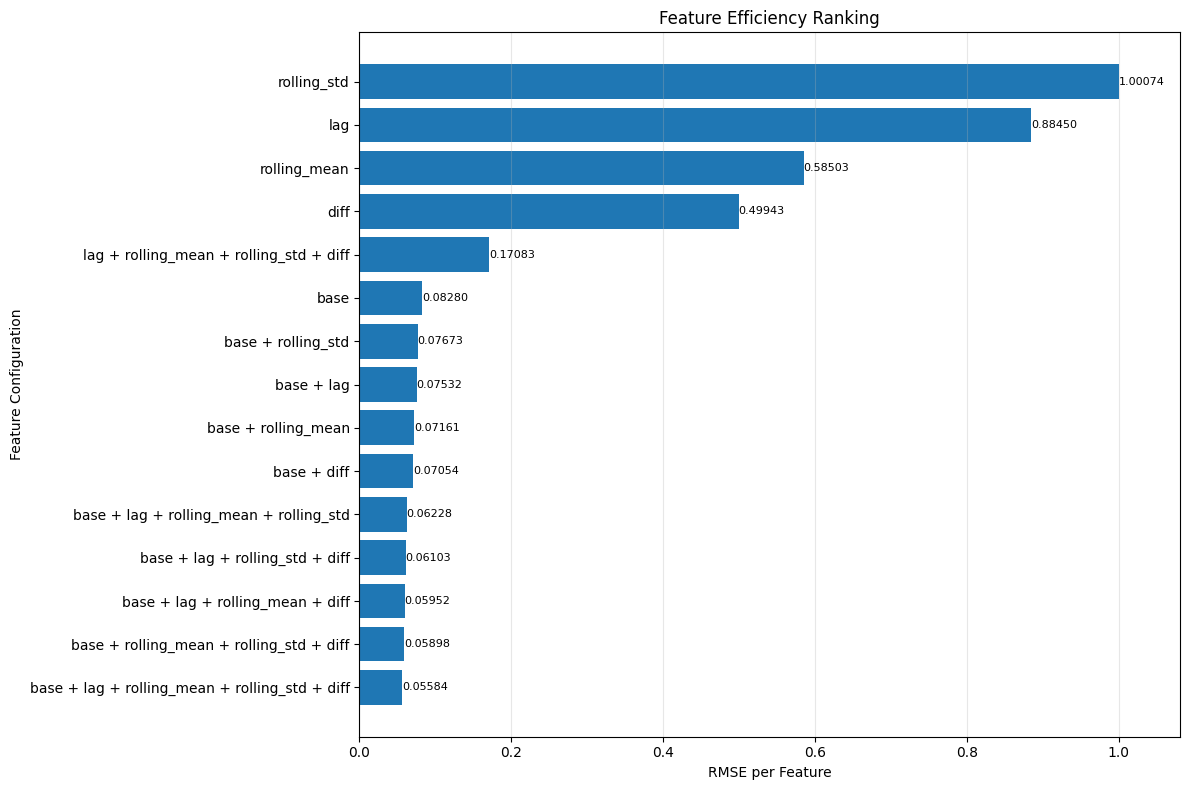

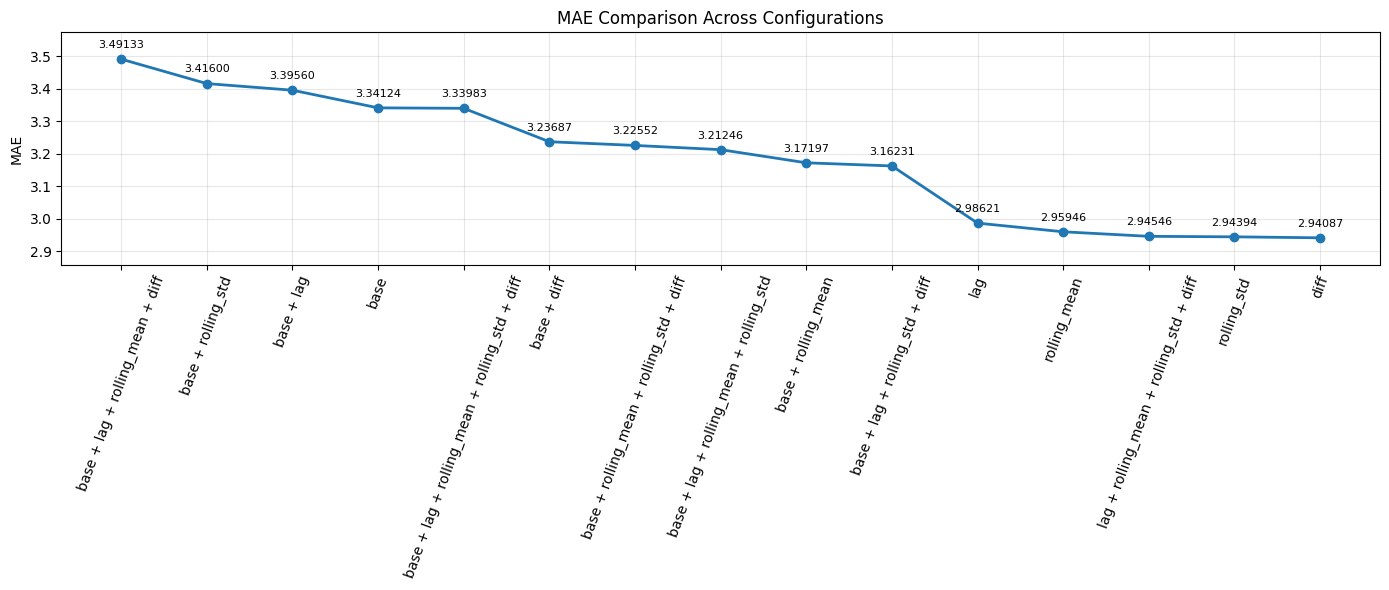

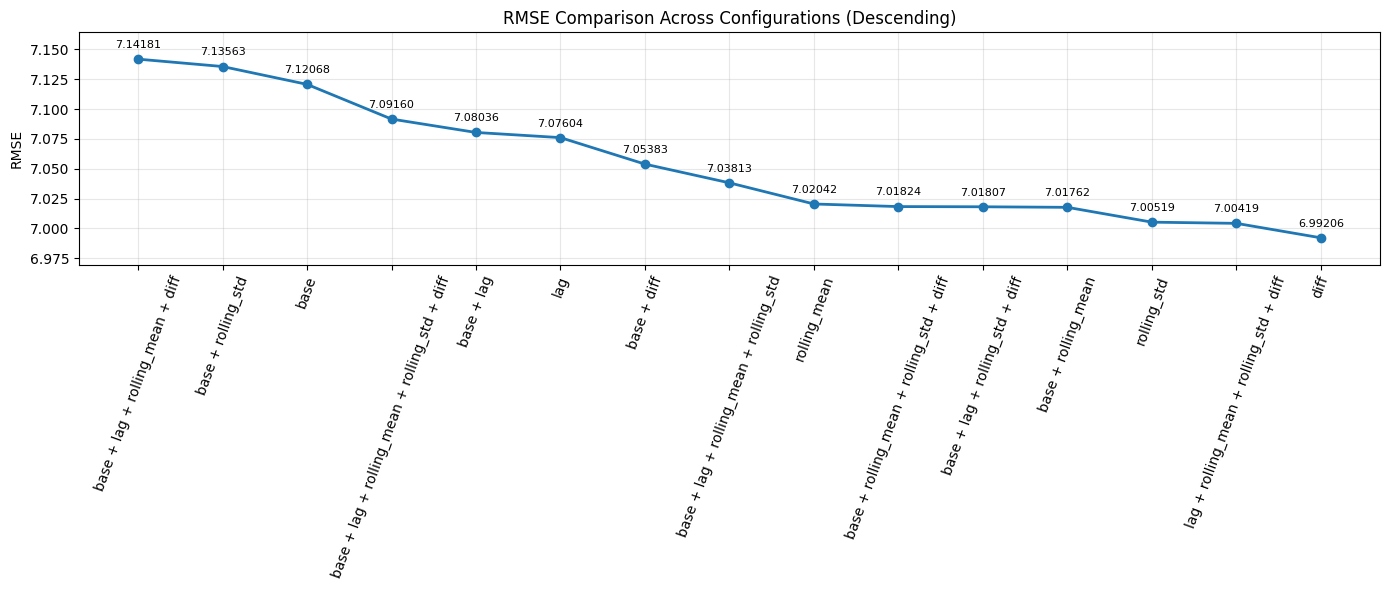

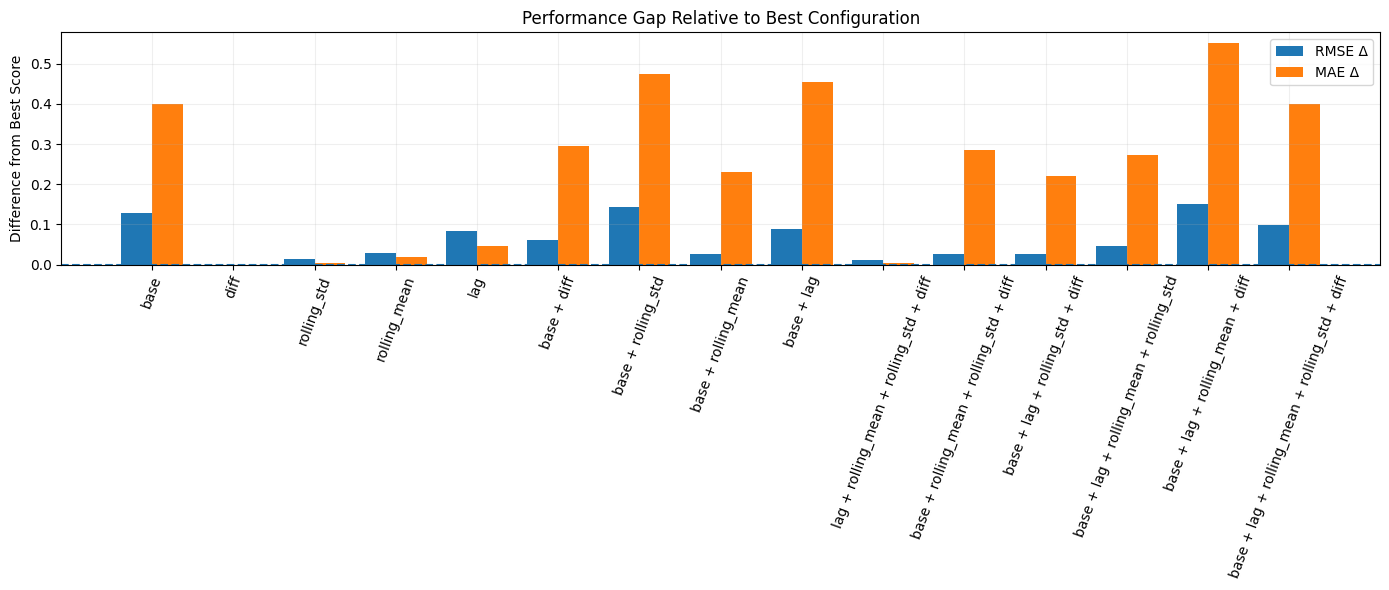

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#!pip install adjustText
#from adjustText import adjust_text

results_df = results_df.sort("weighted_rmse")
configs = results_df["config"].to_list()
weighted_rmse = results_df["weighted_rmse"].to_list()
rmse = results_df["rmse"].to_list()
mae = results_df["mae"].to_list()
num_features = results_df["num_features"].to_list()
x = np.arange(len(configs))

# 1. FEATURE EFFICIENCY BAR CHART

efficiency = [
    r / f if f > 0 else np.nan
    for r, f in zip(rmse, num_features)
]

sorted_idx = np.argsort(efficiency)[::-1]

sorted_configs = [configs[i] for i in sorted_idx]
sorted_efficiency = [efficiency[i] for i in sorted_idx]


plt.figure(figsize=(12, 8))

bars = plt.barh(
    sorted_configs,
    sorted_efficiency
)

plt.gca().invert_yaxis()


for i, v in enumerate(sorted_efficiency):
    plt.text(
        v,
        i,
        f"{v:.5f}",
        va="center",
        fontsize=8
    )

plt.xlabel("RMSE per Feature")
plt.ylabel("Feature Configuration")

plt.title("Feature Efficiency Ranking")

plt.grid(axis="x", alpha=0.3)
plt.xlim(0, max(sorted_efficiency) * 1.08)
plt.tight_layout()
plt.show()
print(" ")

# 2. MAE COMPARISON

sorted_idx = np.argsort(mae)[::-1]

mae_sorted = [mae[i] for i in sorted_idx]
configs_sorted = [configs[i] for i in sorted_idx]

x_sorted = np.arange(len(mae_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x_sorted, mae_sorted, marker="o", linewidth=2)

padding = (max(mae_sorted) - min(mae_sorted)) * 0.15

plt.ylim(
    min(mae_sorted) - padding,
    max(mae_sorted) + padding
)


for i, v in enumerate(mae_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x_sorted[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x_sorted, configs_sorted, rotation=70)

plt.ylabel("MAE")
plt.title("MAE Comparison Across Configurations")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")


# 3. RMSE COMPARISON
sorted_data = sorted(
    zip(configs, rmse),
    key=lambda t: t[1],
    reverse=True
)

configs_sorted, rmse_sorted = zip(*sorted_data)

x = range(len(configs_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x, rmse_sorted, marker="o", linewidth=2)

padding = (max(rmse_sorted) - min(rmse_sorted)) * 0.15

plt.ylim(
    min(rmse_sorted) - padding,
    max(rmse_sorted) + padding
)

for i, v in enumerate(rmse_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x, configs_sorted, rotation=70)

plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Configurations (Descending)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")

# 4. DELTA FROM BEST MODEL

best_rmse = min(rmse)
best_mae = min(mae)

rmse_delta = [v - best_rmse for v in rmse]
mae_delta = [v - best_mae for v in mae]

fig, ax = plt.subplots(figsize=(14, 6))

import numpy as np

x = np.arange(len(configs_sorted))

width = 0.38

ax.bar(x - width/2, rmse_delta, width=width, label="RMSE Δ")
ax.bar(x + width/2, mae_delta, width=width, label="MAE Δ")
ax.axhline(0, linestyle="--")

plt.xticks(x, configs, rotation=70)

plt.ylabel("Difference from Best Score")
plt.title("Performance Gap Relative to Best Configuration")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Per-Horizon Models

In [ ]:
horizons = [1, 3, 10, 25]

def evaluate_horizon_model(
    train_df,
    horizon_value,
    model,
    features,
    target,
    weight,
    splits
):

    # -----------------------------------------
    # Filter horizon
    # -----------------------------------------
    df_h = train_df.filter(pl.col(HORIZON) == horizon_value)

    print(f"\n===== Horizon {horizon_value} =====")
    print(df_h.shape)

    # -----------------------------------------
    # Build matrices
    # -----------------------------------------
    X_h = df_h.select(features)
    y_h = df_h.select(target)
    w_h = df_h.select(weight)

    # -----------------------------------------
    # Time splits
    # -----------------------------------------
    tscv = TimeSeriesSplit(n_splits=5, gap=50)
    splits_h = list(tscv.split(X_h))

    # -----------------------------------------
    # Train
    # -----------------------------------------
    oof_preds = train_model(
        X_h,
        y_h,
        w_h,
        splits_h,
        model
    )

    # -----------------------------------------
    # Metrics
    # -----------------------------------------

    fold_scores, mean_rmse, mean_mae = (
        compute_fold_metrics(
            y_h,
            oof_preds,
            splits_h
        )
    )

    weighted_score = weighted_rmse(
        y_h.to_numpy().flatten(),
        oof_preds,
        w_h.to_numpy().flatten()
    )

    print(f"RMSE: {mean_rmse:.4f}")
    print(f"MAE: {mean_mae:.4f}")
    print(f"Weighted: {weighted_score:.6f}")

    return {
        "horizon": horizon_value,
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted": weighted_score
    }

In [ ]:
results = []

for h in [1, 3, 10, 25]:

    result = evaluate_horizon_model(
        train_df=train_df,
        horizon_value=h,
        model=xgboost_model,
        features=FEATURES,
        target=TARGET,
        weight=WEIGHT,
        splits=None
    )

    results.append(result)


===== Horizon 1 =====
(1394653, 94)


shape: (4, 4)
┌─────────┬───────────┬──────────┬──────────┐
│ horizon ┆ rmse      ┆ mae      ┆ weighted │
│ ---     ┆ ---       ┆ ---      ┆ ---      │
│ i64     ┆ f64       ┆ f64      ┆ f64      │
╞═════════╪═══════════╪══════════╪══════════╡
│ 1       ┆ 2.668016  ┆ 1.355324 ┆ 0.0      │
│ 3       ┆ 4.199949  ┆ 2.140239 ┆ 0.0      │
│ 10      ┆ 7.369353  ┆ 3.899705 ┆ 0.0      │
│ 25      ┆ 11.372087 ┆ 6.136192 ┆ 0.0      │
└─────────┴───────────┴──────────┴──────────┘


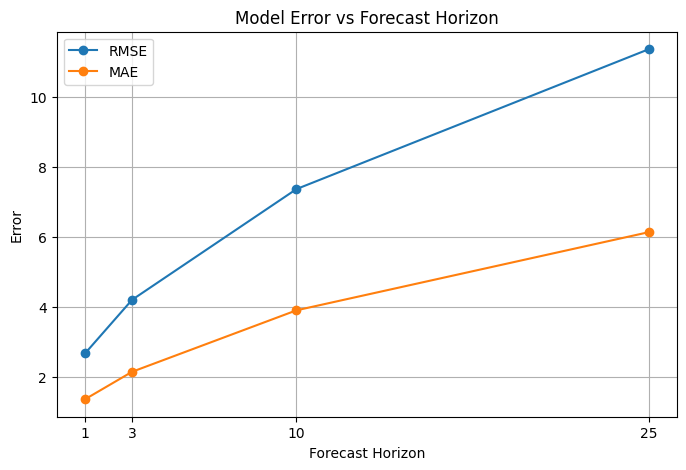

In [ ]:
results_df = pl.DataFrame(results)
print(results_df)

import matplotlib.pyplot as plt

# Sort by horizon just in case
plot_df = results_df.sort("horizon")

# Extract values
horizons = plot_df["horizon"].to_list()
rmse_scores = plot_df["rmse"].to_list()
mae_scores = plot_df["mae"].to_list()

# Create plot
plt.figure(figsize=(8, 5))

plt.plot(
    horizons,
    rmse_scores,
    marker="o",
    label="RMSE"
)

plt.plot(
    horizons,
    mae_scores,
    marker="o",
    label="MAE"
)

# Labels
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.title("Model Error vs Forecast Horizon")

# Ensure exact horizon ticks appear
plt.xticks(horizons)

# Grid + legend
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.base import clone

results = []

for h in horizons:

    print(f"\n===== Horizon {h} =====")

    df_h = train_df.filter(
        pl.col(HORIZON) == h
    )

    X_h_pl = df_h.select(FEATURES)

    X_h = X_h_pl.to_pandas()

    y_h = (
        df_h[TARGET]
        .to_pandas()
        .values
        .ravel()
    )

    corr_values = []

    for feature in FEATURES:

        corr = (
            df_h
            .select(
                pl.corr(feature, TARGET)
            )
            .item()
        )

        corr_values.append(corr)

    model_h = clone(xgboost_model)

    model_h.fit(X_h, y_h)

    importances = model_h.feature_importances_

    feature_df = pd.DataFrame({
        "feature": FEATURES,
        "correlation": corr_values,
        "abs_correlation": np.abs(corr_values),
        "importance": importances
    })

    feature_df["corr_rank"] = (
        feature_df["abs_correlation"]
        .rank(ascending=False)
    )

    feature_df["importance_rank"] = (
        feature_df["importance"]
        .rank(ascending=False)
    )

    feature_df["combined_score"] = (
        (
            1 / feature_df["corr_rank"]
        )
        +
        (
            1 / feature_df["importance_rank"]
        )
    )

    feature_df["horizon"] = h

    feature_df = feature_df.sort_values(
        "combined_score",
        ascending=False
    )

    print("\nTop Combined Features:")
    print(
        feature_df[
            [
                "feature",
                "correlation",
                "importance",
                "combined_score"
            ]
        ].head(15)
    )

    results.append(feature_df)

feature_diagnostics_df = pd.concat(
    results,
    ignore_index=True
)


===== Horizon 1 =====

Top Combined Features:
       feature  correlation  importance  combined_score
37  feature_al    -0.052491    0.013619        1.076923
56  feature_be     0.000655    0.018863        1.012195
77  feature_bz     0.048622    0.017178        0.750000
81  feature_cd     0.051635    0.012772        0.545455
34  feature_ai    -0.034627    0.016436        0.458333
80  feature_cc     0.050058    0.010111        0.348958
45  feature_at     0.007805    0.016388        0.268868
78  feature_ca     0.038185    0.010239        0.216129
54  feature_bc     0.004796    0.016368        0.215625
76  feature_by     0.037017    0.010264        0.183333
73  feature_bv     0.014248    0.015231        0.182857
16   feature_q     0.002828    0.015874        0.180556
79  feature_cb     0.035399    0.008450        0.155203
18   feature_s     0.030388    0.012745        0.151111
55  feature_bd     0.000387    0.014303        0.137048

===== Horizon 3 =====

Top Combined Features:
       fea

In [ ]:
import os
import polars as pl

if not os.path.exists("horizon-feature-corr-results.parquet"):
        print("Downloading results...")
        !gdown --id 1h7WhfGfB7000WdUSCXp0aRK4owmrPN_E -O horizon-feature-corr-results.parquet

print("Loading data...")
feature_diagnostics_results = pl.scan_parquet("horizon-feature-corr-results.parquet").collect()
print(feature_diagnostics_results)

In [ ]:
print(feature_diagnostics_results.shape)
print(feature_diagnostics_results)

(344, 8)
shape: (344, 8)
┌────────────┬────────────┬────────────┬────────────┬───────────┬────────────┬───────────┬─────────┐
│ feature    ┆ correlatio ┆ abs_correl ┆ importance ┆ corr_rank ┆ importance ┆ combined_ ┆ horizon │
│ ---        ┆ n          ┆ ation      ┆ ---        ┆ ---       ┆ _rank      ┆ score     ┆ ---     │
│ str        ┆ ---        ┆ ---        ┆ f32        ┆ f64       ┆ ---        ┆ ---       ┆ i64     │
│            ┆ f64        ┆ f64        ┆            ┆           ┆ f64        ┆ f64       ┆         │
╞════════════╪════════════╪════════════╪════════════╪═══════════╪════════════╪═══════════╪═════════╡
│ feature_al ┆ -0.052491  ┆ 0.052491   ┆ 0.013619   ┆ 1.0       ┆ 13.0       ┆ 1.076923  ┆ 1       │
│ feature_be ┆ 0.000655   ┆ 0.000655   ┆ 0.018863   ┆ 82.0      ┆ 1.0        ┆ 1.012195  ┆ 1       │
│ feature_bz ┆ 0.048622   ┆ 0.048622   ┆ 0.017178   ┆ 4.0       ┆ 2.0        ┆ 0.75      ┆ 1       │
│ feature_cd ┆ 0.051635   ┆ 0.051635   ┆ 0.012772   ┆ 2.0       ┆ 

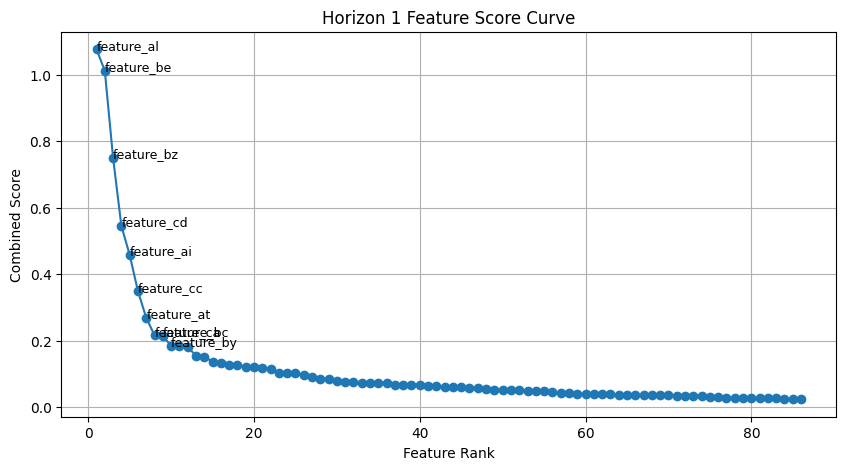

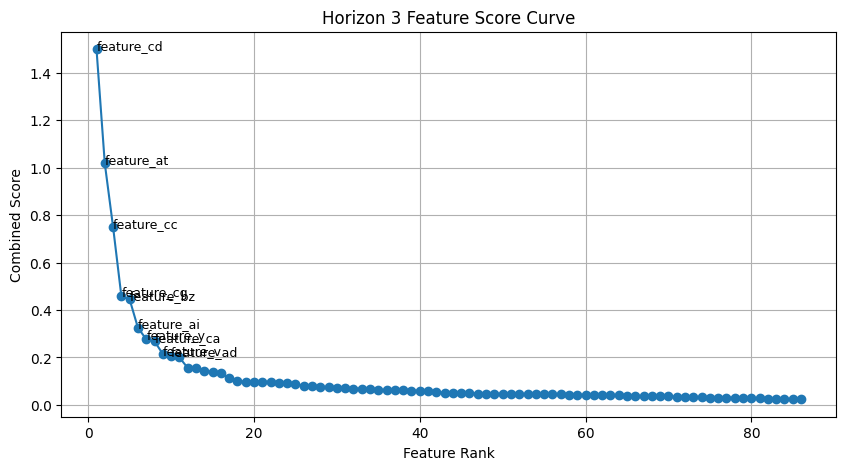

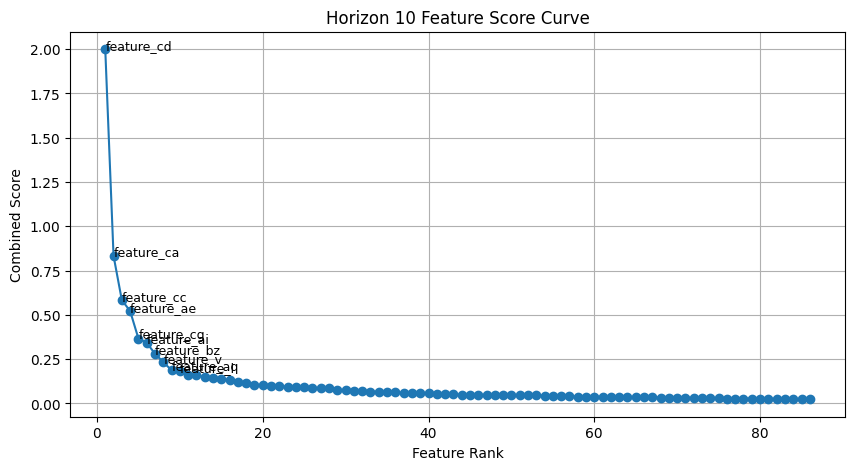

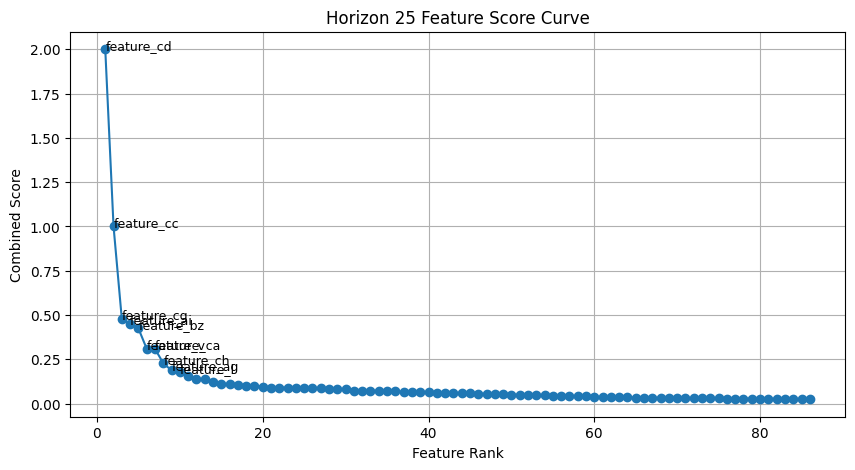

In [ ]:
import matplotlib.pyplot as plt

feature_df = feature_diagnostics_results.to_pandas()

horizons = sorted(
    feature_df["horizon"].unique()
)

for h in horizons:

    df_plot = (
        feature_df[
            feature_df["horizon"] == h
        ]
        .sort_values(
            "combined_score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    df_plot["rank"] = df_plot.index + 1

    plt.figure(figsize=(10, 5))

    plt.plot(
        df_plot["rank"],
        df_plot["combined_score"],
        marker="o"
    )

    top_n = 10

    for i in range(min(top_n, len(df_plot))):

        plt.text(
            df_plot.loc[i, "rank"],
            df_plot.loc[i, "combined_score"],
            df_plot.loc[i, "feature"],
            fontsize=9
        )

    plt.title(f"Horizon {h} Feature Score Curve")
    plt.xlabel("Feature Rank")
    plt.ylabel("Combined Score")

    plt.grid(True)

    plt.show()

## Feature Engineering per Horizon Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

def plot_pred_vs_actual(y_true, y_pred, horizon):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(12, 5))

    plt.plot(y_true[:500], label="Actual", alpha=0.7)
    plt.plot(y_pred[:500], label="Predicted", alpha=0.7)

    plt.title(f"Horizon {horizon}: Predicted vs Actual (first 500 samples)")
    plt.xlabel("Time index")
    plt.ylabel("Target value")
    plt.legend()

    plt.show()

def scatter_pred_vs_actual(y_true, y_pred, horizon):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(6, 6))

    plt.scatter(y_true, y_pred, alpha=0.3)

    # perfect prediction line
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())

    plt.plot([min_v, max_v], [min_v, max_v], 'r--')

    plt.title(f"Horizon {horizon}: Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.show()

In [ ]:
from sklearn.base import clone
import numpy as np

def add_target_encoding_fold(df, train_idx, val_idx):
    train_df = df[train_idx]
    global_mean = train_df[TARGET].mean()

    enc = (
        train_df
        .group_by(CODE)
        .agg(pl.col(TARGET).mean().alias("code_te"))
    )

    global_mean = train_df[TARGET].mean()


    df = df.with_columns(
        pl.col(CODE).map_elements(
            lambda x: enc.filter(pl.col(CODE) == x)["code_te"][0]
            if enc.filter(pl.col(CODE) == x).height > 0
            else global_mean,
            return_dtype=pl.Float64
        ).alias("code_target_enc")
    )

    return df


def train_model(df, engineered_cols, model, weight_col=WEIGHT):
    tscv = TimeSeriesSplit(n_splits=5, gap=50)
    splits = list(tscv.split(df))

    oof = np.zeros(len(df))

    for train_idx, val_idx in splits:

        df_fold = add_target_encoding_fold(df.clone(), train_idx, val_idx)

        cols = engineered_cols + ["code_target_enc"]

        X_train = df_fold[train_idx].select(cols).to_numpy()
        X_val   = df_fold[val_idx].select(cols).to_numpy()

        y_train = df_fold[train_idx].select(TARGET).to_numpy().flatten()
        y_val   = df_fold[val_idx].select(TARGET).to_numpy().flatten()

        w_np = df_fold[weight_col].to_numpy().flatten()

        baseline = np.median(y_train)
        y_train_proc = y_train - baseline

        p95 = np.percentile(np.abs(y_train), 95)
        p99 = np.percentile(np.abs(y_train), 99)

        w_train = np.where(
            np.abs(y_train) > p99, 8.0,
            np.where(np.abs(y_train) > p95, 3.0, 1.0)
        )

        combined_weights = w_train * w_np[train_idx]

        m = clone(model)
        m.fit(X_train, y_train_proc, sample_weight=combined_weights)

        preds = m.predict(X_val)
        preds = preds + baseline
        preds = np.tanh(preds / 5.0) * 5.0

        print("Pred std:", preds.std())
        print("Pred mean:", preds.mean())

        oof[val_idx] = preds

    return oof, splits



HORIZON 1
Pred std: 0.6252995552002372
Pred mean: 0.05394337362497128
Pred std: 0.06976538098067969
Pred mean: -0.00029521810181111404
Pred std: 0.05041784369817668
Pred mean: 0.005797546659513863
Pred std: 0.3387986391814233
Pred mean: 0.00012455019000830815
Pred std: 0.6480868071732594
Pred mean: -0.12909265690962587
RMSE: 2.5051
MAE: 1.0272
Weighted: 0.000000


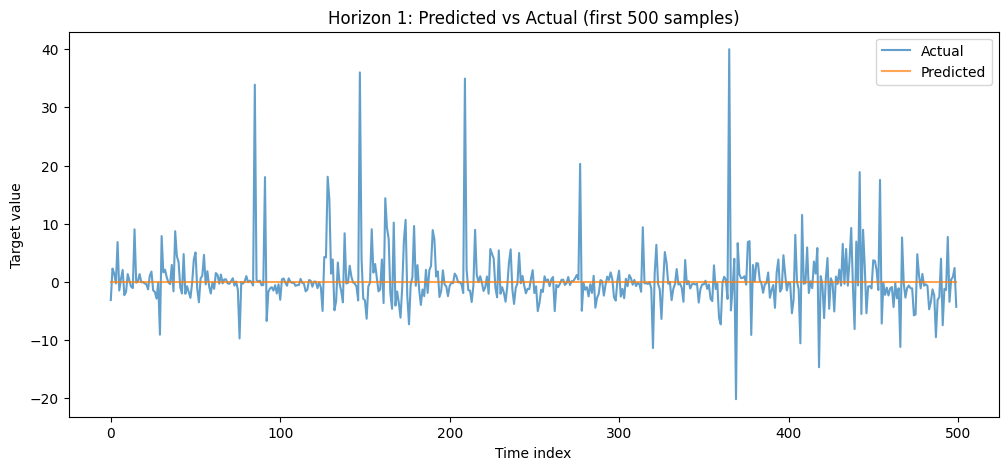

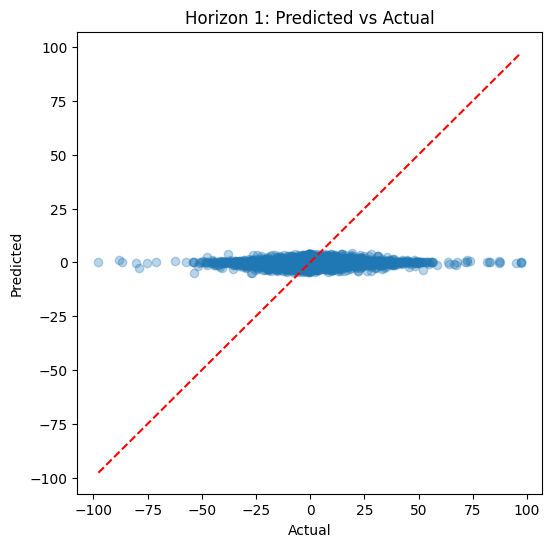


HORIZON 3
Pred std: 1.2685657786642055
Pred mean: 0.16365107496456885
Pred std: 0.13531495486323414
Pred mean: 0.009429250982518336
Pred std: 0.02939267480459374
Pred mean: -0.0010288240186338265
Pred std: 0.5614316972503387
Pred mean: -0.15814160451520545
Pred std: 1.2323875603631527
Pred mean: -0.6395622115541226
RMSE: 4.1402
MAE: 1.8949
Weighted: 0.000000


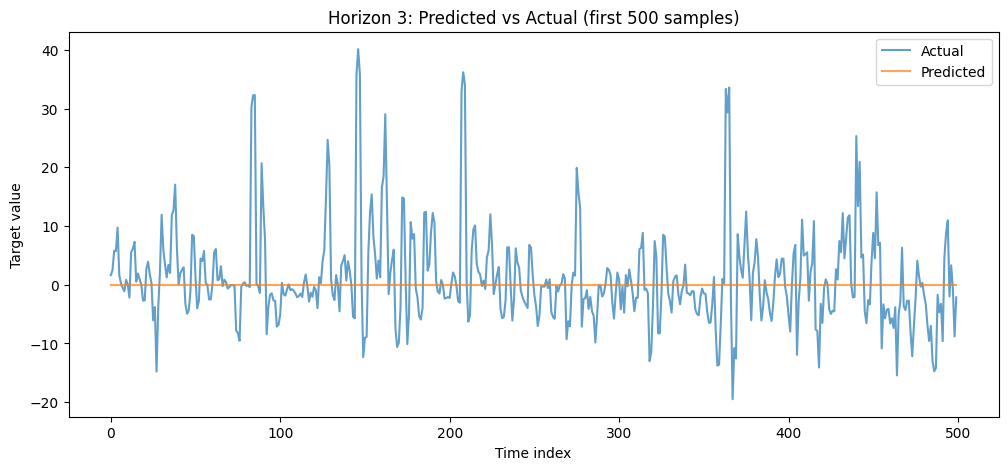

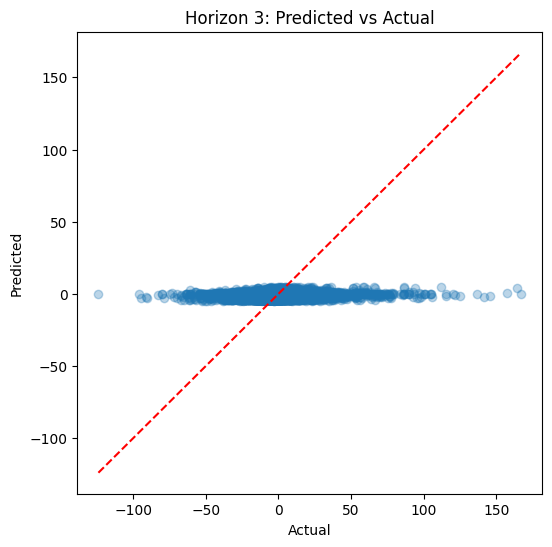


HORIZON 10
Pred std: 1.399029524908799
Pred mean: -0.8516167828647272
Pred std: 0.1289583824162913
Pred mean: 0.021282587204424507
Pred std: 0.20209263454698217
Pred mean: -0.0012595100112842016
Pred std: 1.0577066171849163
Pred mean: -0.22147960346994788
Pred std: 1.9673993686374738
Pred mean: -0.6816539123219784
RMSE: 7.3372
MAE: 3.4604
Weighted: 0.000000


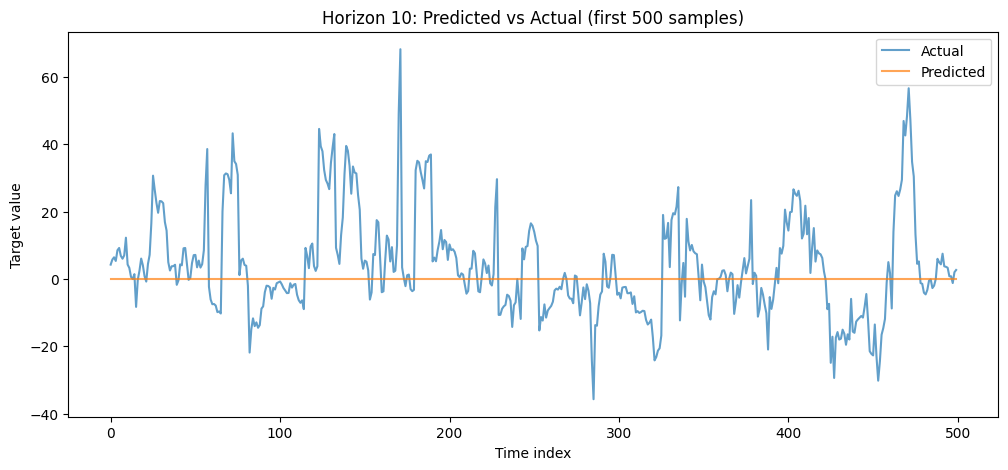

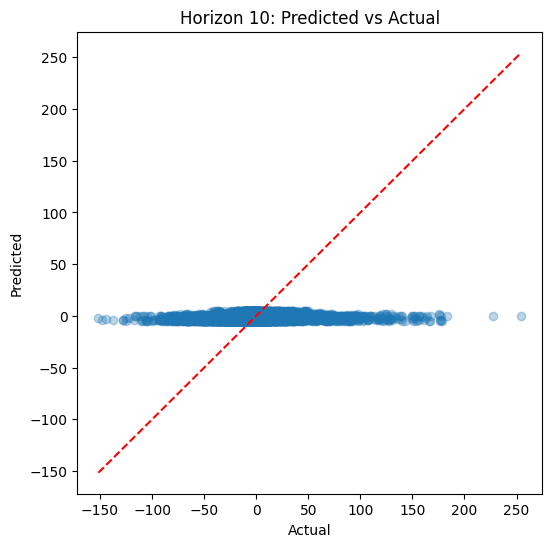


HORIZON 25
Pred std: 1.9498351167413885
Pred mean: -2.3358987535269127
Pred std: 0.6584219223040008
Pred mean: 0.019521204589689818
Pred std: 0.4185261533324526
Pred mean: -0.06916553047264146
Pred std: 2.0591513353573667
Pred mean: -0.5408044309895704
Pred std: 2.6268924186326665
Pred mean: -1.7102409094749471
RMSE: 11.0973
MAE: 5.6348
Weighted: 0.000000


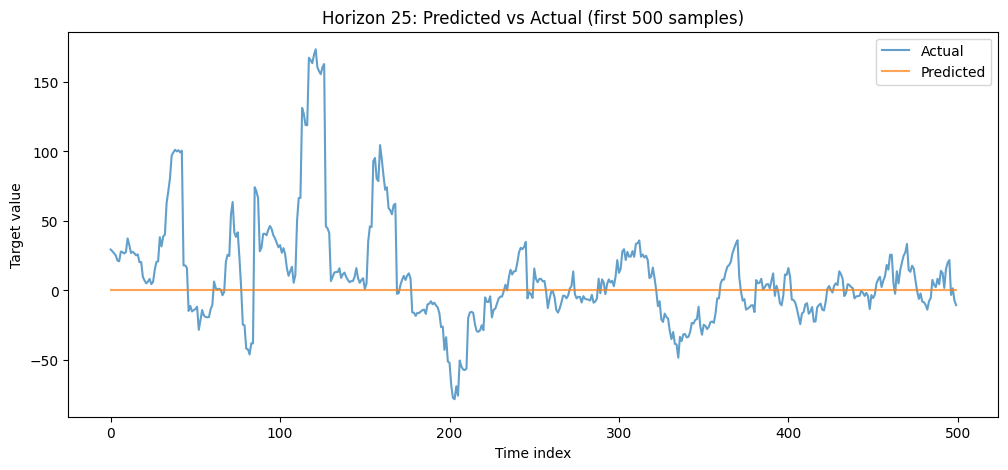

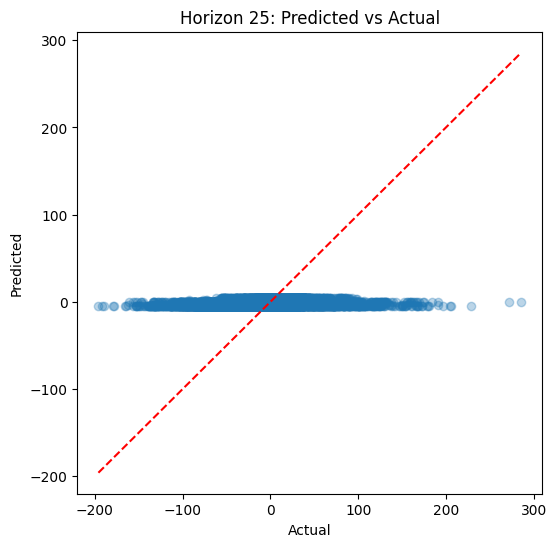

shape: (4, 5)
┌─────────┬───────────┬──────────┬──────────┬──────────────┐
│ horizon ┆ rmse      ┆ mae      ┆ weighted ┆ num_features │
│ ---     ┆ ---       ┆ ---      ┆ ---      ┆ ---          │
│ i64     ┆ f64       ┆ f64      ┆ f64      ┆ i64          │
╞═════════╪═══════════╪══════════╪══════════╪══════════════╡
│ 1       ┆ 2.505098  ┆ 1.027184 ┆ 0.0      ┆ 72           │
│ 3       ┆ 4.140209  ┆ 1.894941 ┆ 0.0      ┆ 99           │
│ 10      ┆ 7.337242  ┆ 3.460402 ┆ 0.0      ┆ 36           │
│ 25      ┆ 11.097293 ┆ 5.634805 ┆ 0.0      ┆ 63           │
└─────────┴───────────┴──────────┴──────────┴──────────────┘

FINAL WEIGHTED SCORE: 0.000000


In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

horizons = [1, 3, 10, 25]

xgboost_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.5,
    reg_alpha=0.0,
    gamma=0,
    objective="reg:pseudohubererror",
    huber_slope=5.0,
    random_state=SEED,
    max_delta_step=2,
    n_jobs=-1
)

HORIZON_FEATURES = {

    1: [
        "feature_al",
        "feature_be",
        "feature_bz",
        "feature_cd",
        "feature_ai",
        "feature_cc",
        "feature_at",
        "feature_ca",
        "feature_bc"
    ],

    3: [
        "feature_cd",
        "feature_at",
        "feature_cc",
        "feature_cg",
        "feature_bz",
        "feature_ai",
        "feature_y",
        "feature_ca",
        "feature_v",
        "feature_ad",
        "feature_by"
    ],

    10: [
        "feature_cd",
        "feature_ca",
        "feature_cc",
        "feature_ae"
    ],

    25: [
        "feature_cd",
        "feature_cc",
        "feature_cg",
        "feature_ai",
        "feature_bz",
        "feature_v",
        "feature_ca"
    ]
}


HORIZON_CONFIG = {


    1: {
        "lags": [1, 3],
        "windows": [3, 5]
    },


    3: {
        "lags": [1, 3, 5],
        "windows": [3, 5]
    },


    10: {
        "lags": [3, 5, 10],
        "windows": [5, 10]
    },


    25: {
        "lags": [5, 10, 25],
        "windows": [10, 25]
    }
}


GROUP_COLS = [CODE, SUBCODE, SUBCATEGORY]

def build_horizon_features(
    df,
    base_features,
    horizon_value
):


    exprs = []

    lags = HORIZON_CONFIG[horizon_value]["lags"]
    windows = HORIZON_CONFIG[horizon_value]["windows"]

    for feature in base_features:

        for lag in lags:


            exprs.append(
                pl.col(feature)
                .shift(lag)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_lag_{lag}"
                )
            )


        for w in windows:


            shifted = (
                pl.col(feature)
                .shift(1)
            )


            exprs.append(
                shifted
                .rolling_mean(w)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_rollmean_{w}"
                )
            )


            exprs.append(
                shifted
                .rolling_std(w)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_rollstd_{w}"
                )
            )


        exprs.append(
            pl.col(feature)
            .diff()
            .over(GROUP_COLS)
            .alias(
                f"{feature}_diff"
            )
        )

    df_new = df.with_columns(exprs)

    return df_new


results = []

all_y = []
all_oof = []
all_w = []

for h in horizons:

    print("\n==============================")
    print(f"HORIZON {h}")
    print("==============================")

    df_h = train_df.filter(pl.col(HORIZON) == h)

    base_features = HORIZON_FEATURES[h]

    df_h = build_horizon_features(df_h, base_features, h)

    engineered_cols = [
        c for c in df_h.columns
        if any(c == f or c.startswith(f"{f}_") for f in base_features)
        and c not in [TARGET, WEIGHT, "ts_index"]
    ]

    df_h = df_h.drop_nulls(subset=engineered_cols)

    oof, splits = train_model(df_h, engineered_cols, xgboost_model)

    y = df_h.select(TARGET).to_numpy().flatten()
    w = df_h.select(WEIGHT).to_numpy().flatten()

    all_y.append(y)
    all_oof.append(oof)
    all_w.append(w)

    y = df_h.select(TARGET).to_numpy().flatten()
    w = df_h.select(WEIGHT).to_numpy().flatten()

    rmse, mae = compute_fold_metrics(y, oof, splits)[1:]
    weighted = weighted_rmse(y, oof, w)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Weighted: {weighted:.6f}")

    plot_pred_vs_actual(y, oof, h)
    scatter_pred_vs_actual(y, oof, h)


    results.append({
        "horizon": h,
        "rmse": rmse,
        "mae": mae,
        "weighted": weighted,
        "num_features": len(engineered_cols)
    })


results_df = pl.DataFrame(results).sort("horizon")
print(results_df)

y_all = np.concatenate(all_y)
oof_all = np.concatenate(all_oof)
w_all = np.concatenate(all_w)

final_score = weighted_rmse(
    y_all,
    oof_all,
    w_all
)

print("\n===================================")
print(f"FINAL WEIGHTED SCORE: {final_score:.6f}")
print("===================================")